In [1]:
from pathlib import Path
import os

#Nachfragen wie man das elegante lösen könnte!

# Immer sicher: Projektroot anhand dieser Datei bestimmen
notebook_dir = Path(os.getcwd())

# Nur hochgehen wenn wir noch in notebooks/ sind
if notebook_dir.name == "notebooks":
    os.chdir(notebook_dir.parent)

print(os.getcwd())  # Kontrolle: muss in sds210-final-project enden

/Users/christophhueppi/Documents/Universität_Zürich/Geographie/Master/FS-26/GEO-876/sds210-final-project


In [2]:
import pandas as pd
import geopandas as gpd

# 1. Load
zwn_df = pd.read_csv("data/raw/stzh.zwn_meldungen_p.csv")

print("Data loaded successfully!")

# 2. Peek
display(zwn_df.head(10))
display(zwn_df.tail(10))

# 3. Shape & Columns
print(zwn_df.shape)
print(zwn_df.columns.values)
display(zwn_df.info())

Data loaded successfully!


,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry
0,1,1,2013-03-14T15:16:15,2013-04-04T07:25:05,2013-04-12T07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548)
1,2,2,2013-03-14T15:17:57,2013-03-26T14:05:05,2013-04-12T08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916)
2,3,4,2013-03-15T09:14:16,2013-03-15T09:55:05,2013-04-12T08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431)
3,4,5,2013-03-15T09:17:15,2013-03-20T10:05:05,2013-04-12T08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Par,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376)
4,5,6,2013-03-15T10:36:53,2013-04-22T18:25:05,2013-04-23T13:50:33,2683094,1247762,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,16624,Arbeitskist,Arbeitskiste ist rund herum verschmiert,https://www.zueriwieneu.ch/photo/6.0.jpeg?8e65...,Web interface,Dieses Graffiti wird von uns in den kommenden ...,Arbeitskist: Arbeitskiste ist rund herum versc...,https://www.zueriwieneu.ch/report/6,POINT (2683094 1247762)
5,6,7,2013-03-16T17:54:42,2013-03-28T07:10:05,2013-04-12T08:09:44,2683475,1247422,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Gelockerte,Gelockerte und fehlende Pflastersteine auf der...,https://www.zueriwieneu.ch/photo/7.0.jpeg?eefa...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Gelockerte : Gelockerte und fehlende Pflasters...,https://www.zueriwieneu.ch/report/7,POINT (2683475 1247422)
6,7,8,2013-03-16T18:04:21,2013-05-06T15:50:05,2013-05-06T17:29:11,2683303,1247675,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Steinerne B,"Steinerne Ballustrade bei der Uraniawache, Bah...",https://www.zueriwieneu.ch/photo/8.0.jpeg?9461...,Web interface,Für diesen Bereich ist die Immobilienbewirtsch...,Steinerne B: Steinerne Ballustrade bei der Ura...,https://www.zueriwieneu.ch/report/8,POINT (2683303 1247675)
7,8,9,2013-03-18T07:06:53,2013-03-19T17:10:05,2013-04-12T08:18:43,2678769,1248921,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Feldblumens,"Feldblumenstrasse 30, Schlagloch",NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,"Feldblumens: Feldblumenstrasse 30, Schlagloch",https://www.zueriwieneu.ch/report/9,POINT (2678769 1248921)
8,9,10,2013-03-18T07:16:54,2013-03-19T09:40:05,2013-04-12T08:19:25,2678479,1248732,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Rautistrass,Rautistrasse / Friedhofstrasse: Schlagloch im ...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Rautistrass: Rautistrasse / Friedhofstrasse: S...,https://www.zueriwieneu.ch/report/10,POINT (2678479 1248732)
9,10,11,2013-03-20T07:20:37,2013-03-20T10:05:05,2013-04-12T08:11:54,2682529,125134

,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry
72918,72919,81475,2026-05-08T09:43:08,2026-05-08T09:47:05,2026-05-08T11:20:47,2681853,1246346,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,3029,Ein Sofa li,Ein Sofa liegt unter der Brücke.,https://www.zueriwieneu.ch/photo/81475.0.jpeg?...,mobile,Entsorgung + Recycling Zürich holt den gemelde...,Ein Sofa li: Ein Sofa liegt unter der Brücke.,https://www.zueriwieneu.ch/report/81475,POINT (2681853 1246346)
72919,72920,81477,2026-05-08T10:39:03,2026-05-08T11:12:05,2026-05-08T11:12:05,2681282,1242686,Allgemein,Allgemein,external,3971,Dieser Roll,Dieser Roller steht schon seit 3 Wochen auf de...,https://www.zueriwieneu.ch/photo/81477.0.jpeg?...,desktop,Vielen Dank für Ihre Meldung. Wir haben sie an...,Dieser Roll: Dieser Roller steht schon seit 3 ...,https://www.zueriwieneu.ch/report/81477,POINT (2681282 1242686)
72920,72921,81478,2026-05-08T10:52:45,2026-05-08T10:57:05,2026-05-08T12:22:43,2684828,1251822,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,12710,Gruezi mite,Gruezi mitenand Da wurde offebar diese Woche n...,NaN,iOS,Entsorgung + Recycling Zürich leitet Ihr Anlie...,Gruezi mite: Gruezi mitenand Da wurde offebar ...,https://www.zueriwieneu.ch/report/81478,POINT (2684828 1251822)
72921,72922,81479,2026-05-08T11:00:26,2026-05-08T11:02:07,2026-05-08T11:25:56,2681016,1249418,Beleuchtung/Uhren,Beleuchtung/Uhren,fixed - council,6076,Light on du,Light on during day,NaN,iOS,Besten Dank für Ihre Nachricht. <br/> Dass die...,Light on du: Light on during day,https://www.zueriwieneu.ch/report/81479,POINT (2681016 1249418)
72922,72923,81480,2026-05-08T11:08:39,2026-05-08T11:12:05,2026-05-08T17:19:05,2678944,1247548,Schädlinge,Schädlinge,fixed - council,18925,Warscheinli,Warscheinlich Gespinstmotte¨ <br/> <br/> Bin ...,https://www.zueriwieneu.ch/photo/81480.0.jpeg?...,desktop,Vielen Dank für Ihre Meldung. Die Gespinstmott...,Warscheinli: Warscheinlich Gespinstmotte¨ <br/...,https://www.zueriwieneu.ch/report/81480,POINT (2678944 1247548)
72923,72924,81485,2026-05-08T12:35:15,2026-05-08T12:37:06,2026-05-08T13:37:04,2680717,1246225,Signalisation/Lichtsignal,Signalisation/Lichtsignal,fixed - council,16680,HV Tafel ve,HV Tafel verdreht,https://www.zueriwieneu.ch/photo/81485.0.jpeg?...,iOS,Guten Tag und vielen Dank für Ihre Meldung. <b...,HV Tafel ve: HV Tafel verdreht,https://www.zueriwieneu.ch/report/81485,POINT (2680717 1246225)
72924,72925,81488,2026-05-08T14:22:41,2026-05-08T14:27:06,2026-05-08T16:40:54,2681081,1248091,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,14824,Teppich,Teppich,https://www.zueriwieneu.ch/photo/81488.0.jpeg?...,iOS,Entsorgung + Recycling Zürich holt den gemelde...,Teppich: Teppich,https://www.zueriwieneu.ch/report/81488,POINT (2681081 1248091)
72925,72926,81489,2026-05-08T14:48:24,2026-05-08T14:52:05,2026-05-08T15:23:37,2686121,1246921,Signalisation/Lichtsignal,Signalisation/Lichtsignal,fixed - council,14768,Markierung,Markierung ist nicht abgeschlossen oder fehlt.,NaN,iOS,Guten Tag <br/> <br/> Vielen Dank für Ihren w...,Markierung : Markierung ist nicht abgeschlosse...,https://www.zueriwieneu.ch/report/81489,POINT (2686121 1246921)
72926,72927,81491,2026-05-08T15:13:14,2026-05-08T15:17:06,2026-05-08T15:25:27,2681238,1247791,Signalisation/Lichtsignal,Signalisation/Lichtsignal,fixed - council,17363,HV Tafel ve,HV Tafel verklebt,https://www.zueriwieneu.ch/photo/81491.0.jpeg?...,iOS,Guten Tag <br/> <br/> Vielen Dank für Ihren w...,HV Tafel ve: HV Tafel verklebt,https://www.zueriwieneu.ch/report/81491,POINT (2681238 1247791)
72927,72928,81493,2026-05-08T15:49:21,2026-05-08T15:52:05,2026-05-08T16:23:23,2681239,1247764,Signalisation/Lichtsignal,Signalisation/Lichtsignal,fixed - council,17363,HV Tafel ve,HV Tafel verklebt und abgedreht.,https://www.zueriwieneu.ch/photo/81493.0.jpeg?...,iOS,

(72928, 19)
<ArrowStringArray>
[            'objectid',   'service_request_id',   'requested_datetime',
 'agency_sent_datetime',     'updated_datetime',                    'e',
                    'n',         'service_code',         'service_name',
               'status',               'userid',                'title',
               'detail',            'media_url',       'interface_used',
       'service_notice',          'description',                  'url',
             'geometry']
Length: 19, dtype: str
<class 'pandas.DataFrame'>
RangeIndex: 72928 entries, 0 to 72927
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   objectid              72928 non-null  int64
 1   service_request_id    72928 non-null  int64
 2   requested_datetime    72928 non-null  str  
 3   agency_sent_datetime  72104 non-null  str  
 4   updated_datetime      72928 non-null  str  
 5   e                     72928 non-null 

None

In [3]:
for col in zwn_df.columns:
    if col.endswith("_datetime"):
        zwn_df[col] = pd.to_datetime(
            zwn_df[col],
            errors="coerce"
        )

In [4]:
display(zwn_df.info())
display(zwn_df.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 72928 entries, 0 to 72927
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   objectid              72928 non-null  int64         
 1   service_request_id    72928 non-null  int64         
 2   requested_datetime    72928 non-null  datetime64[us]
 3   agency_sent_datetime  72104 non-null  datetime64[us]
 4   updated_datetime      72928 non-null  datetime64[us]
 5   e                     72928 non-null  int64         
 6   n                     72928 non-null  int64         
 7   service_code          72928 non-null  str           
 8   service_name          72928 non-null  str           
 9   status                72928 non-null  str           
 10  userid                72928 non-null  int64         
 11  title                 72926 non-null  str           
 12  detail                72926 non-null  str           
 13  media_url             50194

None

,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry
0,1,1,2013-03-14 15:16:15,2013-04-04 07:25:05,2013-04-12 07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548)
1,2,2,2013-03-14 15:17:57,2013-03-26 14:05:05,2013-04-12 08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916)
2,3,4,2013-03-15 09:14:16,2013-03-15 09:55:05,2013-04-12 08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431)
3,4,5,2013-03-15 09:17:15,2013-03-20 10:05:05,2013-04-12 08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Par,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376)
4,5,6,2013-03-15 10:36:53,2013-04-22 18:25:05,2013-04-23 13:50:33,2683094,1247762,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,16624,Arbeitskist,Arbeitskiste ist rund herum verschmiert,https://www.zueriwieneu.ch/photo/6.0.jpeg?8e65...,Web interface,Dieses Graffiti wird von uns in den kommenden ...,Arbeitskist: Arbeitskiste ist rund herum versc...,https://www.zueriwieneu.ch/report/6,POINT (2683094 1247762)
5,6,7,2013-03-16 17:54:42,2013-03-28 07:10:05,2013-04-12 08:09:44,2683475,1247422,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Gelockerte,Gelockerte und fehlende Pflastersteine auf der...,https://www.zueriwieneu.ch/photo/7.0.jpeg?eefa...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Gelockerte : Gelockerte und fehlende Pflasters...,https://www.zueriwieneu.ch/report/7,POINT (2683475 1247422)
6,7,8,2013-03-16 18:04:21,2013-05-06 15:50:05,2013-05-06 17:29:11,2683303,1247675,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Steinerne B,"Steinerne Ballustrade bei der Uraniawache, Bah...",https://www.zueriwieneu.ch/photo/8.0.jpeg?9461...,Web interface,Für diesen Bereich ist die Immobilienbewirtsch...,Steinerne B: Steinerne Ballustrade bei der Ura...,https://www.zueriwieneu.ch/report/8,POINT (2683303 1247675)
7,8,9,2013-03-18 07:06:53,2013-03-19 17:10:05,2013-04-12 08:18:43,2678769,1248921,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Feldblumens,"Feldblumenstrasse 30, Schlagloch",NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,"Feldblumens: Feldblumenstrasse 30, Schlagloch",https://www.zueriwieneu.ch/report/9,POINT (2678769 1248921)
8,9,10,2013-03-18 07:16:54,2013-03-19 09:40:05,2013-04-12 08:19:25,2678479,1248732,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Rautistrass,Rautistrasse / Friedhofstrasse: Schlagloch im ...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Rautistrass: Rautistrasse / Friedhofstrasse: S...,https://www.zueriwieneu.ch/report/10,POINT (2678479 1248732)
9,10,11,2013-03-20 07:20:37,2013-03-20 10:05:05,2013-04-12 08:11:54,2682529,125134

In [5]:
# Save DataFrame to a new CSV file
# We use index=False to prevent saving the sequential row numbers
zwn_df.to_csv("data/processed/stzh.zwn_meldungen_p_datetime64.csv", index=False)

print("File successfully saved!")

File successfully saved!


In [6]:
# 1. Make a safe copy
zwn_interp = zwn_df.copy()

# 2. Use interpolate() to connect the dots between the day before and day after
zwn_interp["agency_sent_datetime"] = zwn_interp["agency_sent_datetime"].interpolate()

display(zwn_interp.info())
display(zwn_interp.head(4))

<class 'pandas.DataFrame'>
RangeIndex: 72928 entries, 0 to 72927
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   objectid              72928 non-null  int64         
 1   service_request_id    72928 non-null  int64         
 2   requested_datetime    72928 non-null  datetime64[us]
 3   agency_sent_datetime  72928 non-null  datetime64[us]
 4   updated_datetime      72928 non-null  datetime64[us]
 5   e                     72928 non-null  int64         
 6   n                     72928 non-null  int64         
 7   service_code          72928 non-null  str           
 8   service_name          72928 non-null  str           
 9   status                72928 non-null  str           
 10  userid                72928 non-null  int64         
 11  title                 72926 non-null  str           
 12  detail                72926 non-null  str           
 13  media_url             50194

None

,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry
0,1,1,2013-03-14 15:16:15,2013-04-04 07:25:05,2013-04-12 07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548)
1,2,2,2013-03-14 15:17:57,2013-03-26 14:05:05,2013-04-12 08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916)
2,3,4,2013-03-15 09:14:16,2013-03-15 09:55:05,2013-04-12 08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431)
3,4,5,2013-03-15 09:17:15,2013-03-20 10:05:05,2013-04-12 08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Par,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376)


In [7]:
for col in zwn_interp.columns:
    if col.endswith("_datetime"):

        new_col = col.replace("_datetime", "_date")

        zwn_interp[new_col] = (
            zwn_interp[col]
            .dt.normalize()
        )


display(zwn_interp.info())
display(zwn_interp.head(4))

<class 'pandas.DataFrame'>
RangeIndex: 72928 entries, 0 to 72927
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   objectid              72928 non-null  int64         
 1   service_request_id    72928 non-null  int64         
 2   requested_datetime    72928 non-null  datetime64[us]
 3   agency_sent_datetime  72928 non-null  datetime64[us]
 4   updated_datetime      72928 non-null  datetime64[us]
 5   e                     72928 non-null  int64         
 6   n                     72928 non-null  int64         
 7   service_code          72928 non-null  str           
 8   service_name          72928 non-null  str           
 9   status                72928 non-null  str           
 10  userid                72928 non-null  int64         
 11  title                 72926 non-null  str           
 12  detail                72926 non-null  str           
 13  media_url             50194

None

,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,...,detail,media_url,interface_used,service_notice,description,url,geometry,requested_date,agency_sent_date,updated_date
0,1,1,2013-03-14 15:16:15,2013-04-04 07:25:05,2013-04-12 07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Auf dem Asphalt des Bürgersteigs hat es eine E...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548),2013-03-14,2013-04-04,2013-04-12
1,2,2,2013-03-14 15:17:57,2013-03-26 14:05:05,2013-04-12 08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Vermessungspunkt ist nicht mehr bündig mit dem...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916),2013-03-14,2013-03-26,2013-04-12
2,3,4,2013-03-15 09:14:16,2013-03-15 09:55:05,2013-04-12 08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431),2013-03-15,2013-03-15,2013-04-12
3,4,5,2013-03-15 09:17:15,2013-03-20 10:05:05,2013-04-12 08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376),2013-03-15,2013-03-20,2013-04-12


In [8]:
zwn_interp = zwn_interp.rename(
    columns={"geometry": "geometry_zwn"}
)

display(zwn_interp.info())

<class 'pandas.DataFrame'>
RangeIndex: 72928 entries, 0 to 72927
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   objectid              72928 non-null  int64         
 1   service_request_id    72928 non-null  int64         
 2   requested_datetime    72928 non-null  datetime64[us]
 3   agency_sent_datetime  72928 non-null  datetime64[us]
 4   updated_datetime      72928 non-null  datetime64[us]
 5   e                     72928 non-null  int64         
 6   n                     72928 non-null  int64         
 7   service_code          72928 non-null  str           
 8   service_name          72928 non-null  str           
 9   status                72928 non-null  str           
 10  userid                72928 non-null  int64         
 11  title                 72926 non-null  str           
 12  detail                72926 non-null  str           
 13  media_url             50194

None

In [9]:
# Save DataFrame to a new CSV file
# We use index=False to prevent saving the sequential row numbers
zwn_interp.to_csv("data/processed/stzh.zwn_meldungen_p_datetime64_normalized.csv", index=False)

print("File successfully saved!")

File successfully saved!


In [10]:
zwn_interp["requested_date"].min()

Timestamp('2013-03-14 00:00:00')

In [11]:
# 2. Explore the columns to find the coordinate names
print("Columns in CSV:", zwn_interp.columns.values)

# 2. Peek
display(zwn_interp.head(10))
display(zwn_interp.tail(10))

# 3. Shape & Columns
print(zwn_interp.shape)
print(zwn_interp.columns.values)
display(zwn_interp.info())

Columns in CSV: <ArrowStringArray>
[            'objectid',   'service_request_id',   'requested_datetime',
 'agency_sent_datetime',     'updated_datetime',                    'e',
                    'n',         'service_code',         'service_name',
               'status',               'userid',                'title',
               'detail',            'media_url',       'interface_used',
       'service_notice',          'description',                  'url',
         'geometry_zwn',       'requested_date',     'agency_sent_date',
         'updated_date']
Length: 22, dtype: str


,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,...,detail,media_url,interface_used,service_notice,description,url,geometry_zwn,requested_date,agency_sent_date,updated_date
0,1,1,2013-03-14 15:16:15,2013-04-04 07:25:05,2013-04-12 07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Auf dem Asphalt des Bürgersteigs hat es eine E...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548),2013-03-14,2013-04-04,2013-04-12
1,2,2,2013-03-14 15:17:57,2013-03-26 14:05:05,2013-04-12 08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Vermessungspunkt ist nicht mehr bündig mit dem...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916),2013-03-14,2013-03-26,2013-04-12
2,3,4,2013-03-15 09:14:16,2013-03-15 09:55:05,2013-04-12 08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431),2013-03-15,2013-03-15,2013-04-12
3,4,5,2013-03-15 09:17:15,2013-03-20 10:05:05,2013-04-12 08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376),2013-03-15,2013-03-20,2013-04-12
4,5,6,2013-03-15 10:36:53,2013-04-22 18:25:05,2013-04-23 13:50:33,2683094,1247762,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,...,Arbeitskiste ist rund herum verschmiert,https://www.zueriwieneu.ch/photo/6.0.jpeg?8e65...,Web interface,Dieses Graffiti wird von uns in den kommenden ...,Arbeitskist: Arbeitskiste ist rund herum versc...,https://www.zueriwieneu.ch/report/6,POINT (2683094 1247762),2013-03-15,2013-04-22,2013-04-23
5,6,7,2013-03-16 17:54:42,2013-03-28 07:10:05,2013-04-12 08:09:44,2683475,1247422,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Gelockerte und fehlende Pflastersteine auf der...,https://www.zueriwieneu.ch/photo/7.0.jpeg?eefa...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Gelockerte : Gelockerte und fehlende Pflasters...,https://www.zueriwieneu.ch/report/7,POINT (2683475 1247422),2013-03-16,2013-03-28,2013-04-12
6,7,8,2013-03-16 18:04:21,2013-05-06 15:50:05,2013-05-06 17:29:11,2683303,1247675,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,"Steinerne Ballustrade bei der Uraniawache, Bah...",https://www.zueriwieneu.ch/photo/8.0.jpeg?9461...,Web interface,Für diesen Bereich ist die Immobilienbewirtsch...,Steinerne B: Steinerne Ballustrade bei der Ura...,https://www.zueriwieneu.ch/report/8,POINT (2683303 1247675),2013-03-16,2013-05-06,2013-05-06
7,8,9,2013-03-18 07:06:53,2013-03-19 17:10:05,2013-04-12 08:18:43,2678769,1248921,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,"Feldblumenstrasse 30, Schlagloch",NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,"Feldblumens: Feldblumenstrasse 30, Schlagloch",https://www.zueriwieneu.ch/report/9,POINT (2678769 1248921),2013-03-18,2013-03-19,2013-04-12
8,9,10,2013-03-18 07:16:54,2013-03-19 09:40:05,2013-04-12 08:19:25,2678479,1248732,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Rautistrasse / Friedhofstrasse: Schlagloch im ...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Rautistrass: R

,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,...,detail,media_url,interface_used,service_notice,description,url,geometry_zwn,requested_date,agency_sent_date,updated_date
72918,72919,81475,2026-05-08 09:43:08,2026-05-08 09:47:05,2026-05-08 11:20:47,2681853,1246346,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,...,Ein Sofa liegt unter der Brücke.,https://www.zueriwieneu.ch/photo/81475.0.jpeg?...,mobile,Entsorgung + Recycling Zürich holt den gemelde...,Ein Sofa li: Ein Sofa liegt unter der Brücke.,https://www.zueriwieneu.ch/report/81475,POINT (2681853 1246346),2026-05-08,2026-05-08,2026-05-08
72919,72920,81477,2026-05-08 10:39:03,2026-05-08 11:12:05,2026-05-08 11:12:05,2681282,1242686,Allgemein,Allgemein,external,...,Dieser Roller steht schon seit 3 Wochen auf de...,https://www.zueriwieneu.ch/photo/81477.0.jpeg?...,desktop,Vielen Dank für Ihre Meldung. Wir haben sie an...,Dieser Roll: Dieser Roller steht schon seit 3 ...,https://www.zueriwieneu.ch/report/81477,POINT (2681282 1242686),2026-05-08,2026-05-08,2026-05-08
72920,72921,81478,2026-05-08 10:52:45,2026-05-08 10:57:05,2026-05-08 12:22:43,2684828,1251822,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,...,Gruezi mitenand Da wurde offebar diese Woche n...,NaN,iOS,Entsorgung + Recycling Zürich leitet Ihr Anlie...,Gruezi mite: Gruezi mitenand Da wurde offebar ...,https://www.zueriwieneu.ch/report/81478,POINT (2684828 1251822),2026-05-08,2026-05-08,2026-05-08
72921,72922,81479,2026-05-08 11:00:26,2026-05-08 11:02:07,2026-05-08 11:25:56,2681016,1249418,Beleuchtung/Uhren,Beleuchtung/Uhren,fixed - council,...,Light on during day,NaN,iOS,Besten Dank für Ihre Nachricht. <br/> Dass die...,Light on du: Light on during day,https://www.zueriwieneu.ch/report/81479,POINT (2681016 1249418),2026-05-08,2026-05-08,2026-05-08
72922,72923,81480,2026-05-08 11:08:39,2026-05-08 11:12:05,2026-05-08 17:19:05,2678944,1247548,Schädlinge,Schädlinge,fixed - council,...,Warscheinlich Gespinstmotte¨ <br/> <br/> Bin ...,https://www.zueriwieneu.ch/photo/81480.0.jpeg?...,desktop,Vielen Dank für Ihre Meldung. Die Gespinstmott...,Warscheinli: Warscheinlich Gespinstmotte¨ <br/...,https://www.zueriwieneu.ch/report/81480,POINT (2678944 1247548),2026-05-08,2026-05-08,2026-05-08
72923,72924,81485,2026-05-08 12:35:15,2026-05-08 12:37:06,2026-05-08 13:37:04,2680717,1246225,Signalisation/Lichtsignal,Signalisation/Lichtsignal,fixed - council,...,HV Tafel verdreht,https://www.zueriwieneu.ch/photo/81485.0.jpeg?...,iOS,Guten Tag und vielen Dank für Ihre Meldung. <b...,HV Tafel ve: HV Tafel verdreht,https://www.zueriwieneu.ch/report/81485,POINT (2680717 1246225),2026-05-08,2026-05-08,2026-05-08
72924,72925,81488,2026-05-08 14:22:41,2026-05-08 14:27:06,2026-05-08 16:40:54,2681081,1248091,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,...,Teppich,https://www.zueriwieneu.ch/photo/81488.0.jpeg?...,iOS,Entsorgung + Recycling Zürich holt den gemelde...,Teppich: Teppich,https://www.zueriwieneu.ch/report/81488,POINT (2681081 1248091),2026-05-08,2026-05-08,2026-05-08
72925,72926,81489,2026-05-08 14:48:24,2026-05-08 14:52:05,2026-05-08 15:23:37,2686121,1246921,Signalisation/Lichtsignal,Signalisation/Lichtsignal,fixed - council,...,Markierung ist nicht abgeschlossen oder fehlt.,NaN,iOS,Guten Tag <br/> <br/> Vielen Dank für Ihren w...,Markierung : Markierung ist nicht abgeschlosse...,https://www.zueriwieneu.ch/report/81489,POINT (2686121 1246921),2026-05-08,2026-05-08,2026-05-08
72926,72927,81491,2026-05-08 15:13:14,2026-05-08 15:17:06,2026-05-08 15:25:27,2681238,1247791,Signalisation/Lichtsignal,Signalisation/Lichtsignal,fixed - council,...,HV Tafel verklebt,https://www.zueriwieneu.ch/photo/81491.0.jpeg?...,iOS,Guten Tag <br/> <br/> Vielen Dank für Ihren w...,HV Tafel ve: HV Tafel verklebt,https://www.zueriwieneu.ch/report/81491,POINT (2681238 1247791),2026-05-08,2026-05-08,2026-05-08
72927,72928,81493,2026-05-08 15:49:21,2026-05-08

(72928, 22)
<ArrowStringArray>
[            'objectid',   'service_request_id',   'requested_datetime',
 'agency_sent_datetime',     'updated_datetime',                    'e',
                    'n',         'service_code',         'service_name',
               'status',               'userid',                'title',
               'detail',            'media_url',       'interface_used',
       'service_notice',          'description',                  'url',
         'geometry_zwn',       'requested_date',     'agency_sent_date',
         'updated_date']
Length: 22, dtype: str
<class 'pandas.DataFrame'>
RangeIndex: 72928 entries, 0 to 72927
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   objectid              72928 non-null  int64         
 1   service_request_id    72928 non-null  int64         
 2   requested_datetime    72928 non-null  datetime64[us]
 3   agency_sent_datet

None

In [12]:
from shapely import wkt

# WKT -> Geometrie konvertieren
zwn_interp["geometry_zwn"] = zwn_interp["geometry_zwn"].apply(wkt.loads)

# GeoDataFrame erstellen
zwn_interp_gdf = gpd.GeoDataFrame(zwn_interp, geometry="geometry_zwn")

# CRS setzen (wahrscheinlich LV95 / EPSG:2056)
zwn_interp_gdf = zwn_interp_gdf.set_crs(epsg=2056)

# 2. Peek
# Inspect the Coordinate Reference System
print(zwn_interp_gdf.crs)
display(zwn_interp_gdf.head(10))
display(zwn_interp_gdf.tail(10))

# 3. Shape & Columns
print(zwn_interp_gdf.shape)
print(zwn_interp_gdf.columns.values)
print(zwn_interp_gdf.crs)
display(zwn_interp_gdf.info())

EPSG:2056


,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,...,detail,media_url,interface_used,service_notice,description,url,geometry_zwn,requested_date,agency_sent_date,updated_date
0,1,1,2013-03-14 15:16:15,2013-04-04 07:25:05,2013-04-12 07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Auf dem Asphalt des Bürgersteigs hat es eine E...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548),2013-03-14,2013-04-04,2013-04-12
1,2,2,2013-03-14 15:17:57,2013-03-26 14:05:05,2013-04-12 08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Vermessungspunkt ist nicht mehr bündig mit dem...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916),2013-03-14,2013-03-26,2013-04-12
2,3,4,2013-03-15 09:14:16,2013-03-15 09:55:05,2013-04-12 08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431),2013-03-15,2013-03-15,2013-04-12
3,4,5,2013-03-15 09:17:15,2013-03-20 10:05:05,2013-04-12 08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376),2013-03-15,2013-03-20,2013-04-12
4,5,6,2013-03-15 10:36:53,2013-04-22 18:25:05,2013-04-23 13:50:33,2683094,1247762,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,...,Arbeitskiste ist rund herum verschmiert,https://www.zueriwieneu.ch/photo/6.0.jpeg?8e65...,Web interface,Dieses Graffiti wird von uns in den kommenden ...,Arbeitskist: Arbeitskiste ist rund herum versc...,https://www.zueriwieneu.ch/report/6,POINT (2683094 1247762),2013-03-15,2013-04-22,2013-04-23
5,6,7,2013-03-16 17:54:42,2013-03-28 07:10:05,2013-04-12 08:09:44,2683475,1247422,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Gelockerte und fehlende Pflastersteine auf der...,https://www.zueriwieneu.ch/photo/7.0.jpeg?eefa...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Gelockerte : Gelockerte und fehlende Pflasters...,https://www.zueriwieneu.ch/report/7,POINT (2683475 1247422),2013-03-16,2013-03-28,2013-04-12
6,7,8,2013-03-16 18:04:21,2013-05-06 15:50:05,2013-05-06 17:29:11,2683303,1247675,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,"Steinerne Ballustrade bei der Uraniawache, Bah...",https://www.zueriwieneu.ch/photo/8.0.jpeg?9461...,Web interface,Für diesen Bereich ist die Immobilienbewirtsch...,Steinerne B: Steinerne Ballustrade bei der Ura...,https://www.zueriwieneu.ch/report/8,POINT (2683303 1247675),2013-03-16,2013-05-06,2013-05-06
7,8,9,2013-03-18 07:06:53,2013-03-19 17:10:05,2013-04-12 08:18:43,2678769,1248921,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,"Feldblumenstrasse 30, Schlagloch",NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,"Feldblumens: Feldblumenstrasse 30, Schlagloch",https://www.zueriwieneu.ch/report/9,POINT (2678769 1248921),2013-03-18,2013-03-19,2013-04-12
8,9,10,2013-03-18 07:16:54,2013-03-19 09:40:05,2013-04-12 08:19:25,2678479,1248732,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Rautistrasse / Friedhofstrasse: Schlagloch im ...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Rautistrass: R

,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,...,detail,media_url,interface_used,service_notice,description,url,geometry_zwn,requested_date,agency_sent_date,updated_date
72918,72919,81475,2026-05-08 09:43:08,2026-05-08 09:47:05,2026-05-08 11:20:47,2681853,1246346,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,...,Ein Sofa liegt unter der Brücke.,https://www.zueriwieneu.ch/photo/81475.0.jpeg?...,mobile,Entsorgung + Recycling Zürich holt den gemelde...,Ein Sofa li: Ein Sofa liegt unter der Brücke.,https://www.zueriwieneu.ch/report/81475,POINT (2681853 1246346),2026-05-08,2026-05-08,2026-05-08
72919,72920,81477,2026-05-08 10:39:03,2026-05-08 11:12:05,2026-05-08 11:12:05,2681282,1242686,Allgemein,Allgemein,external,...,Dieser Roller steht schon seit 3 Wochen auf de...,https://www.zueriwieneu.ch/photo/81477.0.jpeg?...,desktop,Vielen Dank für Ihre Meldung. Wir haben sie an...,Dieser Roll: Dieser Roller steht schon seit 3 ...,https://www.zueriwieneu.ch/report/81477,POINT (2681282 1242686),2026-05-08,2026-05-08,2026-05-08
72920,72921,81478,2026-05-08 10:52:45,2026-05-08 10:57:05,2026-05-08 12:22:43,2684828,1251822,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,...,Gruezi mitenand Da wurde offebar diese Woche n...,NaN,iOS,Entsorgung + Recycling Zürich leitet Ihr Anlie...,Gruezi mite: Gruezi mitenand Da wurde offebar ...,https://www.zueriwieneu.ch/report/81478,POINT (2684828 1251822),2026-05-08,2026-05-08,2026-05-08
72921,72922,81479,2026-05-08 11:00:26,2026-05-08 11:02:07,2026-05-08 11:25:56,2681016,1249418,Beleuchtung/Uhren,Beleuchtung/Uhren,fixed - council,...,Light on during day,NaN,iOS,Besten Dank für Ihre Nachricht. <br/> Dass die...,Light on du: Light on during day,https://www.zueriwieneu.ch/report/81479,POINT (2681016 1249418),2026-05-08,2026-05-08,2026-05-08
72922,72923,81480,2026-05-08 11:08:39,2026-05-08 11:12:05,2026-05-08 17:19:05,2678944,1247548,Schädlinge,Schädlinge,fixed - council,...,Warscheinlich Gespinstmotte¨ <br/> <br/> Bin ...,https://www.zueriwieneu.ch/photo/81480.0.jpeg?...,desktop,Vielen Dank für Ihre Meldung. Die Gespinstmott...,Warscheinli: Warscheinlich Gespinstmotte¨ <br/...,https://www.zueriwieneu.ch/report/81480,POINT (2678944 1247548),2026-05-08,2026-05-08,2026-05-08
72923,72924,81485,2026-05-08 12:35:15,2026-05-08 12:37:06,2026-05-08 13:37:04,2680717,1246225,Signalisation/Lichtsignal,Signalisation/Lichtsignal,fixed - council,...,HV Tafel verdreht,https://www.zueriwieneu.ch/photo/81485.0.jpeg?...,iOS,Guten Tag und vielen Dank für Ihre Meldung. <b...,HV Tafel ve: HV Tafel verdreht,https://www.zueriwieneu.ch/report/81485,POINT (2680717 1246225),2026-05-08,2026-05-08,2026-05-08
72924,72925,81488,2026-05-08 14:22:41,2026-05-08 14:27:06,2026-05-08 16:40:54,2681081,1248091,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,...,Teppich,https://www.zueriwieneu.ch/photo/81488.0.jpeg?...,iOS,Entsorgung + Recycling Zürich holt den gemelde...,Teppich: Teppich,https://www.zueriwieneu.ch/report/81488,POINT (2681081 1248091),2026-05-08,2026-05-08,2026-05-08
72925,72926,81489,2026-05-08 14:48:24,2026-05-08 14:52:05,2026-05-08 15:23:37,2686121,1246921,Signalisation/Lichtsignal,Signalisation/Lichtsignal,fixed - council,...,Markierung ist nicht abgeschlossen oder fehlt.,NaN,iOS,Guten Tag <br/> <br/> Vielen Dank für Ihren w...,Markierung : Markierung ist nicht abgeschlosse...,https://www.zueriwieneu.ch/report/81489,POINT (2686121 1246921),2026-05-08,2026-05-08,2026-05-08
72926,72927,81491,2026-05-08 15:13:14,2026-05-08 15:17:06,2026-05-08 15:25:27,2681238,1247791,Signalisation/Lichtsignal,Signalisation/Lichtsignal,fixed - council,...,HV Tafel verklebt,https://www.zueriwieneu.ch/photo/81491.0.jpeg?...,iOS,Guten Tag <br/> <br/> Vielen Dank für Ihren w...,HV Tafel ve: HV Tafel verklebt,https://www.zueriwieneu.ch/report/81491,POINT (2681238 1247791),2026-05-08,2026-05-08,2026-05-08
72927,72928,81493,2026-05-08 15:49:21,2026-05-08

(72928, 22)
<ArrowStringArray>
[            'objectid',   'service_request_id',   'requested_datetime',
 'agency_sent_datetime',     'updated_datetime',                    'e',
                    'n',         'service_code',         'service_name',
               'status',               'userid',                'title',
               'detail',            'media_url',       'interface_used',
       'service_notice',          'description',                  'url',
         'geometry_zwn',       'requested_date',     'agency_sent_date',
         'updated_date']
Length: 22, dtype: str
EPSG:2056
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 72928 entries, 0 to 72927
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   objectid              72928 non-null  int64         
 1   service_request_id    72928 non-null  int64         
 2   requested_datetime    72928 non-null  datetime

None

In [27]:
# Export as a GeoPackage (For sharing with QGIS/ArcGIS users)
zwn_interp_gdf.to_file("data/processed/stzh.zwn_meldungen_p_processed.gpkg")

print("File successfully saved!")

File successfully saved!


In [13]:
import pandas as pd

file_path = "data/raw/Bevoelkerung_nach-Herkunft-Stadtkreis-Stadtquartier.xlsx"

# Jahre / Sheets
years = [str(year) for year in range(2025, 2012, -1)]

dfs = []

for year in years:

    # Excel einlesen
    df = pd.read_excel(
        file_path,
        sheet_name=year,
        usecols="A:B",
        skiprows=8,
        header=0,
        engine="openpyxl"
    )

    # Spalten umbenennen
    df.columns = ["qname", f"poptot{year}"]

    # Optional: Leere Zeilen entfernen
    df = df.dropna(subset=["qname"])

    dfs.append(df)

# Alle Jahre über districts zusammenführen
zh_pop_df = dfs[0]

for df in dfs[1:]:
    zh_pop_df = zh_pop_df.merge(df, on="qname", how="outer")

print("Data loaded successfully!")

# 2. Peek
display(zh_pop_df.head(10))
display(zh_pop_df.tail(10))

# 3. Shape & Columns
print(zh_pop_df.shape)
print(zh_pop_df.columns.values)

# Info
zh_pop_df.info()

zh_pop_df["qname"]

Data loaded successfully!


,qname,poptot2025,poptot2024,poptot2023,poptot2022,poptot2021,poptot2020,poptot2019,poptot2018,poptot2017,poptot2016,poptot2015,poptot2014,poptot2013
0,Affoltern,27439,27337,27165,26935,26554,26584,26710,26562,26177,26054,25874,25902,25082
1,Albisrieden,24304,23877,23526,22875,22412,22364,22352,22304,22113,21174,19325,19199,19146
2,Alt-Wiedikon,18904,18610,18115,18079,17631,17764,17874,17956,17522,17321,17158,16918,16706
3,Altstetten,36874,36260,36315,35642,34665,34098,34285,33461,32603,31724,32003,31486,31115
4,City,769,785,806,820,817,829,797,829,830,810,805,791,783
5,Enge,10015,10032,10035,10017,9750,9655,9658,9634,9489,9422,9257,9083,8836
6,Escher Wyss,6426,6077,6185,6225,6221,6198,6188,6066,6088,5825,5457,4604,4010
7,Fluntern,8878,8787,8783,8946,8777,8685,8639,8485,8221,8038,7953,7865,7856
8,Friesenberg,11226,11137,11082,10861,10957,11071,11107,10933,10860,11002,10698,10695,10696
9,Ganze Stadt,452421,448664,447082,443037,436332,434736,434008,428737,423310,415682,410404,404783,398575


,qname,poptot2025,poptot2024,poptot2023,poptot2022,poptot2021,poptot2020,poptot2019,poptot2018,poptot2017,poptot2016,poptot2015,poptot2014,poptot2013
37,Schwamendingen-Mitte,11383,11314,11421,11207,10975,11083,11261,11100,11012,11076,11315,11301,11209
38,Seebach,29320,28336,27677,26980,26541,26056,25806,25568,25817,25198,24991,24431,24008
39,Seefeld,5798,5807,5777,5815,5862,5480,5319,5253,5129,5046,4990,5035,4978
40,Sihlfeld,21478,21687,21753,21642,21516,21921,22141,21680,21660,21177,21339,21195,20931
41,Unterstrass,25576,25078,24801,24953,24489,24493,23971,23394,22768,22476,22226,22126,21876
42,Weinegg,5701,5635,5589,5559,5548,5562,5414,5220,5248,5030,5086,5036,5022
43,Werd,4585,4495,4650,4515,4574,4570,4455,4455,4574,4594,4460,4428,4188
44,Wipkingen,16745,16734,16737,16698,16507,16605,16474,16321,16544,16141,15879,15717,15835
45,Witikon,11984,11747,11690,11402,11255,11244,11054,10953,10600,10667,10639,10406,10267
46,Wollishofen,22029,21800,21181,20570,19937,19757,19225,18923,17892,16567,16244,16137,15937


(47, 14)
<ArrowStringArray>
[     'qname', 'poptot2025', 'poptot2024', 'poptot2023', 'poptot2022',
 'poptot2021', 'poptot2020', 'poptot2019', 'poptot2018', 'poptot2017',
 'poptot2016', 'poptot2015', 'poptot2014', 'poptot2013']
Length: 14, dtype: str
<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   qname       47 non-null     str  
 1   poptot2025  47 non-null     int64
 2   poptot2024  47 non-null     int64
 3   poptot2023  47 non-null     int64
 4   poptot2022  47 non-null     int64
 5   poptot2021  47 non-null     int64
 6   poptot2020  47 non-null     int64
 7   poptot2019  47 non-null     int64
 8   poptot2018  47 non-null     int64
 9   poptot2017  47 non-null     int64
 10  poptot2016  47 non-null     int64
 11  poptot2015  47 non-null     int64
 12  poptot2014  47 non-null     int64
 13  poptot2013  47 non-null     int64
dtypes: int64(13), str(1)
memory u

0                Affoltern
1              Albisrieden
2             Alt-Wiedikon
3               Altstetten
4                     City
5                     Enge
6              Escher Wyss
7                 Fluntern
8              Friesenberg
9              Ganze Stadt
10           Gewerbeschule
11                    Hard
12              Hirslanden
13              Hirzenbach
14             Hochschulen
15               Hottingen
16                   Höngg
17                 Kreis 1
18                Kreis 10
19                Kreis 11
20                Kreis 12
21                 Kreis 2
22                 Kreis 3
23                 Kreis 4
24                 Kreis 5
25                 Kreis 6
26                 Kreis 7
27                 Kreis 8
28                 Kreis 9
29             Langstrasse
30                Leimbach
31               Lindenhof
32               Mühlebach
33              Oberstrass
34                Oerlikon
35                 Rathaus
36                 Saatlen
3

In [14]:
zh_pop_df["qname"]


0                Affoltern
1              Albisrieden
2             Alt-Wiedikon
3               Altstetten
4                     City
5                     Enge
6              Escher Wyss
7                 Fluntern
8              Friesenberg
9              Ganze Stadt
10           Gewerbeschule
11                    Hard
12              Hirslanden
13              Hirzenbach
14             Hochschulen
15               Hottingen
16                   Höngg
17                 Kreis 1
18                Kreis 10
19                Kreis 11
20                Kreis 12
21                 Kreis 2
22                 Kreis 3
23                 Kreis 4
24                 Kreis 5
25                 Kreis 6
26                 Kreis 7
27                 Kreis 8
28                 Kreis 9
29             Langstrasse
30                Leimbach
31               Lindenhof
32               Mühlebach
33              Oberstrass
34                Oerlikon
35                 Rathaus
36                 Saatlen
3

In [15]:
# Save DataFrame to a new CSV file
# We use index=False to prevent saving the sequential row numbers
zh_pop_df.to_csv("data/processed/Bevoelkerung_nach-Herkunft-Stadtkreis-Stadtquartier_cleaned.csv", index=False)

print("File successfully saved!")

File successfully saved!


In [16]:
zh_pop_urbandists = zh_pop_df.copy()

zh_pop_urbandists = zh_pop_urbandists[
    (~zh_pop_urbandists["qname"].str.startswith("Kreis")) &
    (zh_pop_urbandists["qname"] != "Ganze Stadt")
]

zh_pop_urbandists = zh_pop_urbandists.reset_index(drop=True)

# 2. Peek
display(zh_pop_urbandists.head(10))
display(zh_pop_urbandists.tail(10))

# 3. Shape & Columns
print(zh_pop_urbandists.shape)
print(zh_pop_urbandists.columns.values)
display(zh_pop_urbandists.info())

zh_pop_urbandists["qname"]

,qname,poptot2025,poptot2024,poptot2023,poptot2022,poptot2021,poptot2020,poptot2019,poptot2018,poptot2017,poptot2016,poptot2015,poptot2014,poptot2013
0,Affoltern,27439,27337,27165,26935,26554,26584,26710,26562,26177,26054,25874,25902,25082
1,Albisrieden,24304,23877,23526,22875,22412,22364,22352,22304,22113,21174,19325,19199,19146
2,Alt-Wiedikon,18904,18610,18115,18079,17631,17764,17874,17956,17522,17321,17158,16918,16706
3,Altstetten,36874,36260,36315,35642,34665,34098,34285,33461,32603,31724,32003,31486,31115
4,City,769,785,806,820,817,829,797,829,830,810,805,791,783
5,Enge,10015,10032,10035,10017,9750,9655,9658,9634,9489,9422,9257,9083,8836
6,Escher Wyss,6426,6077,6185,6225,6221,6198,6188,6066,6088,5825,5457,4604,4010
7,Fluntern,8878,8787,8783,8946,8777,8685,8639,8485,8221,8038,7953,7865,7856
8,Friesenberg,11226,11137,11082,10861,10957,11071,11107,10933,10860,11002,10698,10695,10696
9,Gewerbeschule,9528,9617,9689,9663,9583,9424,9562,9513,9578,9598,9608,9539,9626


,qname,poptot2025,poptot2024,poptot2023,poptot2022,poptot2021,poptot2020,poptot2019,poptot2018,poptot2017,poptot2016,poptot2015,poptot2014,poptot2013
24,Schwamendingen-Mitte,11383,11314,11421,11207,10975,11083,11261,11100,11012,11076,11315,11301,11209
25,Seebach,29320,28336,27677,26980,26541,26056,25806,25568,25817,25198,24991,24431,24008
26,Seefeld,5798,5807,5777,5815,5862,5480,5319,5253,5129,5046,4990,5035,4978
27,Sihlfeld,21478,21687,21753,21642,21516,21921,22141,21680,21660,21177,21339,21195,20931
28,Unterstrass,25576,25078,24801,24953,24489,24493,23971,23394,22768,22476,22226,22126,21876
29,Weinegg,5701,5635,5589,5559,5548,5562,5414,5220,5248,5030,5086,5036,5022
30,Werd,4585,4495,4650,4515,4574,4570,4455,4455,4574,4594,4460,4428,4188
31,Wipkingen,16745,16734,16737,16698,16507,16605,16474,16321,16544,16141,15879,15717,15835
32,Witikon,11984,11747,11690,11402,11255,11244,11054,10953,10600,10667,10639,10406,10267
33,Wollishofen,22029,21800,21181,20570,19937,19757,19225,18923,17892,16567,16244,16137,15937


(34, 14)
<ArrowStringArray>
[     'qname', 'poptot2025', 'poptot2024', 'poptot2023', 'poptot2022',
 'poptot2021', 'poptot2020', 'poptot2019', 'poptot2018', 'poptot2017',
 'poptot2016', 'poptot2015', 'poptot2014', 'poptot2013']
Length: 14, dtype: str
<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   qname       34 non-null     str  
 1   poptot2025  34 non-null     int64
 2   poptot2024  34 non-null     int64
 3   poptot2023  34 non-null     int64
 4   poptot2022  34 non-null     int64
 5   poptot2021  34 non-null     int64
 6   poptot2020  34 non-null     int64
 7   poptot2019  34 non-null     int64
 8   poptot2018  34 non-null     int64
 9   poptot2017  34 non-null     int64
 10  poptot2016  34 non-null     int64
 11  poptot2015  34 non-null     int64
 12  poptot2014  34 non-null     int64
 13  poptot2013  34 non-null     int64
dtypes: int64(13), str(1)
memory u

None

0                Affoltern
1              Albisrieden
2             Alt-Wiedikon
3               Altstetten
4                     City
5                     Enge
6              Escher Wyss
7                 Fluntern
8              Friesenberg
9            Gewerbeschule
10                    Hard
11              Hirslanden
12              Hirzenbach
13             Hochschulen
14               Hottingen
15                   Höngg
16             Langstrasse
17                Leimbach
18               Lindenhof
19               Mühlebach
20              Oberstrass
21                Oerlikon
22                 Rathaus
23                 Saatlen
24    Schwamendingen-Mitte
25                 Seebach
26                 Seefeld
27                Sihlfeld
28             Unterstrass
29                 Weinegg
30                    Werd
31               Wipkingen
32                 Witikon
33             Wollishofen
Name: qname, dtype: str

In [17]:
# Save DataFrame to a new CSV file
# We use index=False to prevent saving the sequential row numbers
zh_pop_urbandists.to_csv("data/processed/Bevoelkerung_nach-Herkunft-Stadtkreis-Stadtquartier_urbandists.csv", index=False)

print("File successfully saved!")

File successfully saved!


In [18]:
import pandas as pd
import geopandas as gpd

# 1. Load the raw tabular data
zh_dist_df = pd.read_csv("data/raw/stzh.adm_statistische_quartiere_map.csv")

print("Data loaded successfully!")

# 2. Explore the columns to find the coordinate names
print("Columns in CSV:", zh_dist_df.columns.values)

# 2. Peek
display(zh_dist_df.head(10))
display(zh_dist_df.tail(10))

# 3. Shape & Columns
print(zh_dist_df.shape)
print(zh_dist_df.columns.values)
display(zh_dist_df.info())

Data loaded successfully!
Columns in CSV: <ArrowStringArray>
['objectid', 'qnr', 'qname', 'knr', 'kname', 'geometry']
Length: 6, dtype: str


,objectid,qnr,qname,knr,kname,geometry
0,1,73,Hirslanden,7,Kreis 7,"POLYGON ((2684457 1246514.8,2684466.2 1246519,..."
1,2,83,Weinegg,8,Kreis 8,"POLYGON ((2684457.5 1246512.8,2684458.2 124651..."
2,3,82,Mühlebach,8,Kreis 8,"POLYGON ((2684270 1246566.8,2684271.5 1246562...."
3,4,81,Seefeld,8,Kreis 8,"POLYGON ((2683794.2 1246609.9,2683802 1246597...."
4,7,41,Werd,4,Kreis 4,"POLYGON ((2682652 1247587.6,2682650.8 1247585...."
5,8,34,Sihlfeld,3,Kreis 3,"POLYGON ((2681621 1247666.6,2681627.8 1247651...."
6,9,91,Albisrieden,9,Kreis 9,"POLYGON ((2680246.8 1248185,2680242.2 1248180...."
7,10,72,Hottingen,7,Kreis 7,"POLYGON ((2686439 1249239.4,2686493.5 1249242...."
8,5,21,Wollishofen,2,Kreis 2,"POLYGON ((2683465 1243316.9,2683456 1243310.2,..."
9,18,61,Unterstrass,6,Kreis 6,"POLYGON ((2682138.5 1251265.9,2682137 1251268...."


,objectid,qnr,qname,knr,kname,geometry
24,24,71,Fluntern,7,Kreis 7,"POLYGON ((2686340.8 1249189.5,2686329.8 124917..."
25,25,63,Oberstrass,6,Kreis 6,"POLYGON ((2685281.2 1249561.5,2685223.8 124952..."
26,26,121,Saatlen,12,Kreis 12,"POLYGON ((2684869.2 1252256.1,2684928 1252276...."
27,27,119,Seebach,11,Kreis 11,"POLYGON ((2682176.8 1254103.5,2682261.2 125407..."
28,28,33,Friesenberg,3,Kreis 3,"POLYGON ((2681661.8 1245051,2681621 1245034.5,..."
29,29,12,Hochschulen,1,Kreis 1,"POLYGON ((2683993.5 1247428.2,2683993.8 124742..."
30,30,92,Altstetten,9,Kreis 9,"POLYGON ((2680056.5 1249380.6,2680052.5 124937..."
31,31,123,Hirzenbach,12,Kreis 12,"POLYGON ((2686755 1251429.2,2686822.2 1251385...."
32,32,122,Schwamendingen-Mitte,12,Kreis 12,"POLYGON ((2686726.8 1251429.6,2686743 1251415...."
33,33,31,Alt-Wiedikon,3,Kreis 3,"POLYGON ((2681987 1246689,2681974 1246668.1,26..."


(34, 6)
<ArrowStringArray>
['objectid', 'qnr', 'qname', 'knr', 'kname', 'geometry']
Length: 6, dtype: str
<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   objectid  34 non-null     int64
 1   qnr       34 non-null     int64
 2   qname     34 non-null     str  
 3   knr       34 non-null     int64
 4   kname     34 non-null     str  
 5   geometry  34 non-null     str  
dtypes: int64(3), str(3)
memory usage: 486.6 KB


None

In [19]:
from shapely import wkt

# WKT -> Geometrie konvertieren
zh_dist_df["geometry"] = zh_dist_df["geometry"].apply(wkt.loads)

# GeoDataFrame erstellen
zh_dist_gdf = gpd.GeoDataFrame(zh_dist_df, geometry="geometry")

# CRS setzen (wahrscheinlich LV95 / EPSG:2056)
zh_dist_gdf = zh_dist_gdf.set_crs(epsg=2056)

# 2. Peek
# Inspect the Coordinate Reference System
print(zh_dist_gdf.crs)
display(zh_dist_gdf.head(10))
display(zh_dist_gdf.tail(10))

# 3. Shape & Columns
print(zh_dist_gdf.shape)
print(zh_dist_gdf.columns.values)
print(zh_dist_gdf.crs)
display(zh_dist_gdf.info())

EPSG:2056


,objectid,qnr,qname,knr,kname,geometry
0,1,73,Hirslanden,7,Kreis 7,"POLYGON ((2684457 1246514.8, 2684466.2 1246519..."
1,2,83,Weinegg,8,Kreis 8,"POLYGON ((2684457.5 1246512.8, 2684458.2 12465..."
2,3,82,Mühlebach,8,Kreis 8,"POLYGON ((2684270 1246566.8, 2684271.5 1246562..."
3,4,81,Seefeld,8,Kreis 8,"POLYGON ((2683794.2 1246609.9, 2683802 1246597..."
4,7,41,Werd,4,Kreis 4,"POLYGON ((2682652 1247587.6, 2682650.8 1247585..."
5,8,34,Sihlfeld,3,Kreis 3,"POLYGON ((2681621 1247666.6, 2681627.8 1247651..."
6,9,91,Albisrieden,9,Kreis 9,"POLYGON ((2680246.8 1248185, 2680242.2 1248180..."
7,10,72,Hottingen,7,Kreis 7,"POLYGON ((2686439 1249239.4, 2686493.5 1249242..."
8,5,21,Wollishofen,2,Kreis 2,"POLYGON ((2683465 1243316.9, 2683456 1243310.2..."
9,18,61,Unterstrass,6,Kreis 6,"POLYGON ((2682138.5 1251265.9, 2682137 1251268..."


,objectid,qnr,qname,knr,kname,geometry
24,24,71,Fluntern,7,Kreis 7,"POLYGON ((2686340.8 1249189.5, 2686329.8 12491..."
25,25,63,Oberstrass,6,Kreis 6,"POLYGON ((2685281.2 1249561.5, 2685223.8 12495..."
26,26,121,Saatlen,12,Kreis 12,"POLYGON ((2684869.2 1252256.1, 2684928 1252276..."
27,27,119,Seebach,11,Kreis 11,"POLYGON ((2682176.8 1254103.5, 2682261.2 12540..."
28,28,33,Friesenberg,3,Kreis 3,"POLYGON ((2681661.8 1245051, 2681621 1245034.5..."
29,29,12,Hochschulen,1,Kreis 1,"POLYGON ((2683993.5 1247428.2, 2683993.8 12474..."
30,30,92,Altstetten,9,Kreis 9,"POLYGON ((2680056.5 1249380.6, 2680052.5 12493..."
31,31,123,Hirzenbach,12,Kreis 12,"POLYGON ((2686755 1251429.2, 2686822.2 1251385..."
32,32,122,Schwamendingen-Mitte,12,Kreis 12,"POLYGON ((2686726.8 1251429.6, 2686743 1251415..."
33,33,31,Alt-Wiedikon,3,Kreis 3,"POLYGON ((2681987 1246689, 2681974 1246668.1, ..."


(34, 6)
<ArrowStringArray>
['objectid', 'qnr', 'qname', 'knr', 'kname', 'geometry']
Length: 6, dtype: str
EPSG:2056
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   objectid  34 non-null     int64   
 1   qnr       34 non-null     int64   
 2   qname     34 non-null     str     
 3   knr       34 non-null     int64   
 4   kname     34 non-null     str     
 5   geometry  34 non-null     geometry
dtypes: geometry(1), int64(3), str(2)
memory usage: 2.3 KB


None

EPSG:2056


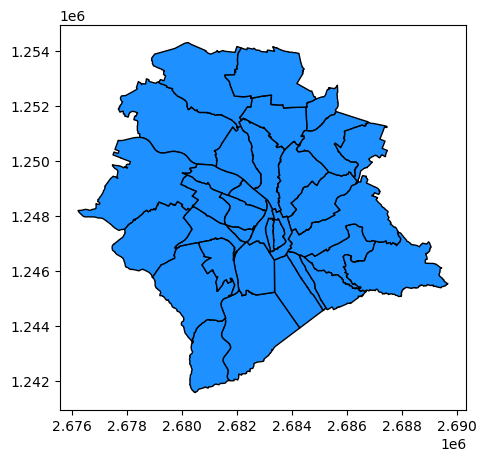

In [20]:
# Instantly visualize the geometric shapes
zh_dist_gdf.plot(figsize=(8, 5), color="dodgerblue", edgecolor="black");
# 2. Peek
print(zh_dist_gdf.crs)

In [28]:
# Export as a GeoPackage (For sharing with QGIS/ArcGIS users)
zh_dist_gdf.to_file("data/processed/stzh.adm_statistische_quartiere_map_processed.gpkg")

print("File successfully saved!")

File successfully saved!


In [21]:
# join
zh_dist_pop_gdf= zh_dist_gdf.merge(zh_pop_urbandists, on="qname", how="outer")

type(zh_dist_pop_gdf)

# 2. Peek
print(zh_dist_pop_gdf.crs)
display(zh_dist_pop_gdf.head(10))
display(zh_dist_pop_gdf.tail(10))

# 3. Shape & Columns
print(zh_dist_pop_gdf.shape)
print(zh_dist_pop_gdf.columns.values)
print(zh_dist_pop_gdf.crs)
display(zh_dist_pop_gdf.info())

EPSG:2056


,objectid,qnr,qname,knr,kname,geometry,poptot2025,poptot2024,poptot2023,poptot2022,poptot2021,poptot2020,poptot2019,poptot2018,poptot2017,poptot2016,poptot2015,poptot2014,poptot2013
0,21,111,Affoltern,11,Kreis 11,"POLYGON ((2679182.5 1252898.6, 2679190.2 12529...",27439,27337,27165,26935,26554,26584,26710,26562,26177,26054,25874,25902,25082
1,9,91,Albisrieden,9,Kreis 9,"POLYGON ((2680246.8 1248185, 2680242.2 1248180...",24304,23877,23526,22875,22412,22364,22352,22304,22113,21174,19325,19199,19146
2,33,31,Alt-Wiedikon,3,Kreis 3,"POLYGON ((2681987 1246689, 2681974 1246668.1, ...",18904,18610,18115,18079,17631,17764,17874,17956,17522,17321,17158,16918,16706
3,30,92,Altstetten,9,Kreis 9,"POLYGON ((2680056.5 1249380.6, 2680052.5 12493...",36874,36260,36315,35642,34665,34098,34285,33461,32603,31724,32003,31486,31115
4,22,14,City,1,Kreis 1,"POLYGON ((2683325.2 1247912.2, 2683325.2 12478...",769,785,806,820,817,829,797,829,830,810,805,791,783
5,11,24,Enge,2,Kreis 2,"POLYGON ((2682901 1245161.8, 2682834 1245151.6...",10015,10032,10035,10017,9750,9655,9658,9634,9489,9422,9257,9083,8836
6,13,52,Escher Wyss,5,Kreis 5,"POLYGON ((2681459.5 1248841.8, 2681440.5 12488...",6426,6077,6185,6225,6221,6198,6188,6066,6088,5825,5457,4604,4010
7,24,71,Fluntern,7,Kreis 7,"POLYGON ((2686340.8 1249189.5, 2686329.8 12491...",8878,8787,8783,8946,8777,8685,8639,8485,8221,8038,7953,7865,7856
8,28,33,Friesenberg,3,Kreis 3,"POLYGON ((2681661.8 1245051, 2681621 1245034.5...",11226,11137,11082,10861,10957,11071,11107,10933,10860,11002,10698,10695,10696
9,34,51,Gewerbeschule,5,Kreis 5,"POLYGON ((2682685 1248920.6, 2682876.8 1248763...",9528,9617,9689,9663,9583,9424,9562,9513,9578,9598,9608,9539,9626


,objectid,qnr,qname,knr,kname,geometry,poptot2025,poptot2024,poptot2023,poptot2022,poptot2021,poptot2020,poptot2019,poptot2018,poptot2017,poptot2016,poptot2015,poptot2014,poptot2013
24,32,122,Schwamendingen-Mitte,12,Kreis 12,"POLYGON ((2686726.8 1251429.6, 2686743 1251415...",11383,11314,11421,11207,10975,11083,11261,11100,11012,11076,11315,11301,11209
25,27,119,Seebach,11,Kreis 11,"POLYGON ((2682176.8 1254103.5, 2682261.2 12540...",29320,28336,27677,26980,26541,26056,25806,25568,25817,25198,24991,24431,24008
26,4,81,Seefeld,8,Kreis 8,"POLYGON ((2683794.2 1246609.9, 2683802 1246597...",5798,5807,5777,5815,5862,5480,5319,5253,5129,5046,4990,5035,4978
27,8,34,Sihlfeld,3,Kreis 3,"POLYGON ((2681621 1247666.6, 2681627.8 1247651...",21478,21687,21753,21642,21516,21921,22141,21680,21660,21177,21339,21195,20931
28,18,61,Unterstrass,6,Kreis 6,"POLYGON ((2682138.5 1251265.9, 2682137 1251268...",25576,25078,24801,24953,24489,24493,23971,23394,22768,22476,22226,22126,21876
29,2,83,Weinegg,8,Kreis 8,"POLYGON ((2684457.5 1246512.8, 2684458.2 12465...",5701,5635,5589,5559,5548,5562,5414,5220,5248,5030,5086,5036,5022
30,7,41,Werd,4,Kreis 4,"POLYGON ((2682652 1247587.6, 2682650.8 1247585...",4585,4495,4650,4515,4574,4570,4455,4455,4574,4594,4460,4428,4188
31,17,102,Wipkingen,10,Kreis 10,"POLYGON ((2682161 1251221.4, 2682183 1251178, ...",16745,16734,16737,16698,16507,16605,16474,16321,16544,16141,15879,15717,15835
32,14,74,Witikon,7,Kreis 7,"POLYGON ((2687854.8 1247430.8, 2687856.5 12474...",11984,11747,11690,11402,11255,11244,11054,10953,10600,10667,10639,10406,10267
33,5,21,Wollishofen,2,Kreis 2,"POLYGON ((2683465 1243316.9, 2683456 1243310.2...",22029,21800,21181,20570,19937,19757,19225,18923,17892,16567,16244,16137,15937


(34, 19)
<ArrowStringArray>
[  'objectid',        'qnr',      'qname',        'knr',      'kname',
   'geometry', 'poptot2025', 'poptot2024', 'poptot2023', 'poptot2022',
 'poptot2021', 'poptot2020', 'poptot2019', 'poptot2018', 'poptot2017',
 'poptot2016', 'poptot2015', 'poptot2014', 'poptot2013']
Length: 19, dtype: str
EPSG:2056
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   objectid    34 non-null     int64   
 1   qnr         34 non-null     int64   
 2   qname       34 non-null     str     
 3   knr         34 non-null     int64   
 4   kname       34 non-null     str     
 5   geometry    34 non-null     geometry
 6   poptot2025  34 non-null     int64   
 7   poptot2024  34 non-null     int64   
 8   poptot2023  34 non-null     int64   
 9   poptot2022  34 non-null     int64   
 10  poptot2021  34 non-null     int64   
 11  poptot2

None

In [40]:
# Export as a GeoPackage (For sharing with QGIS/ArcGIS users)
zh_dist_pop_gdf.to_file("data/processed/stzh.adm.pop_statistische_quartiere_map_processed.gpkg")

print("File successfully saved!")

File successfully saved!


In [29]:
zwn_zh_dist_pop_gdf = gpd.sjoin(
    zwn_interp_gdf,
    zh_dist_pop_gdf,
    how="left",
    predicate="intersects"
)

pd.set_option("display.max_columns", None)

zwn_zh_dist_pop_gdf[
    zwn_zh_dist_pop_gdf["index_right"].isna()
]

# 2. Peek
print(zwn_zh_dist_pop_gdf.crs)
display(zwn_zh_dist_pop_gdf.head(10))
display(zwn_zh_dist_pop_gdf.tail(10))

# 3. Shape & Columns
print(zwn_zh_dist_pop_gdf.shape)
print(zwn_zh_dist_pop_gdf.columns.values)
print(zwn_zh_dist_pop_gdf.crs)
display(zwn_zh_dist_pop_gdf.info())

EPSG:2056


,objectid_left,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry_zwn,requested_date,agency_sent_date,updated_date,index_right,objectid_right,qnr,qname,knr,kname,poptot2025,poptot2024,poptot2023,poptot2022,poptot2021,poptot2020,poptot2019,poptot2018,poptot2017,poptot2016,poptot2015,poptot2014,poptot2013
0,1,1,2013-03-14 15:16:15,2013-04-04 07:25:05,2013-04-12 07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548),2013-03-14,2013-04-04,2013-04-12,1.0,9.0,91.0,Albisrieden,9.0,Kreis 9,24304.0,23877.0,23526.0,22875.0,22412.0,22364.0,22352.0,22304.0,22113.0,21174.0,19325.0,19199.0,19146.0
1,2,2,2013-03-14 15:17:57,2013-03-26 14:05:05,2013-04-12 08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916),2013-03-14,2013-03-26,2013-04-12,15.0,19.0,101.0,Höngg,10.0,Kreis 10,24981.0,24810.0,24674.0,24807.0,24510.0,24439.0,24358.0,24020.0,23797.0,23423.0,22320.0,21826.0,21581.0
2,3,4,2013-03-15 09:14:16,2013-03-15 09:55:05,2013-04-12 08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431),2013-03-15,2013-03-15,2013-04-12,23.0,26.0,121.0,Saatlen,12.0,Kreis 12,8852.0,8814.0,8865.0,8826.0,8788.0,8799.0,8841.0,8582.0,8388.0,8283.0,8508.0,7563.0,7280.0
3,4,5,2013-03-15 09:17:15,2013-03-20 10:05:05,2013-04-12 08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Par,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376),2013-03-15,2013-03-20,2013-04-12,31.0,17.0,102.0,Wipkingen,10.0,Kreis 10,16745.0,16734.0,16737.0,16698.0,16507.0,16605.0,16474.0,16321.0,16544.0,16141.0,15879.0,15717.0,15835.0
4,5,6,2013-03-15 10:36:53,2013-04-22 18:25:05,2013-04-23 13:50:33,2683094,1247762,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,16624,Arbeitskist,Arbeitskiste ist rund herum verschmiert,https://www.zueriwieneu.ch/photo/6.0.jpeg?8e65...,Web interface,Dieses Graffiti wird von uns in den kommenden ...,Arbeitskist: Arbeitskiste ist rund herum versc...,https://www.zueriwieneu.ch/report/6,POINT (2683094 1247762),2013-03-15,2013-04-22,2013-04-23,4.0,22.0,14.0,City,1.0,Kreis 1,769.0,785.0,806.0,820.0,817.0,829.0,797.0,829.0,830.0,810.0,805.0,791.0,783.0
5,6,7,2013-03-16 17:54:42,2013-03-28 07:10:05,2013-04-12 08:09:44,2683475,1247422,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Gelockerte,Gelockerte und fehlende Pflastersteine auf der...,https://www.zueriwieneu.ch/photo/7.0.jpeg?eefa...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Gelockerte : Gelockerte und fehlende Pflasters...,https://www.zueriwieneu.ch/report/7,POINT (2683475 1247422),2013-03-16,2013-03-28,2013-04-12,22.0,23.0,11.0,Rathaus,1.0,Kreis 1,3252.0,3260.0,3343.0,3330.0,3275.0,3317.0,3307.0,3267.0,3266.0,3226.0,3197.0,3236.0,3194.0
6,7,8,2013-03-16 18:04:21,2013-05-06 15:50:05,2013-05-

,objectid_left,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry_zwn,requested_date,agency_sent_date,updated_date,index_right,objectid_right,qnr,qname,knr,kname,poptot2025,poptot2024,poptot2023,poptot2022,poptot2021,poptot2020,poptot2019,poptot2018,poptot2017,poptot2016,poptot2015,poptot2014,poptot2013
72918,72919,81475,2026-05-08 09:43:08,2026-05-08 09:47:05,2026-05-08 11:20:47,2681853,1246346,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,3029,Ein Sofa li,Ein Sofa liegt unter der Brücke.,https://www.zueriwieneu.ch/photo/81475.0.jpeg?...,mobile,Entsorgung + Recycling Zürich holt den gemelde...,Ein Sofa li: Ein Sofa liegt unter der Brücke.,https://www.zueriwieneu.ch/report/81475,POINT (2681853 1246346),2026-05-08,2026-05-08,2026-05-08,2.0,33.0,31.0,Alt-Wiedikon,3.0,Kreis 3,18904.0,18610.0,18115.0,18079.0,17631.0,17764.0,17874.0,17956.0,17522.0,17321.0,17158.0,16918.0,16706.0
72919,72920,81477,2026-05-08 10:39:03,2026-05-08 11:12:05,2026-05-08 11:12:05,2681282,1242686,Allgemein,Allgemein,external,3971,Dieser Roll,Dieser Roller steht schon seit 3 Wochen auf de...,https://www.zueriwieneu.ch/photo/81477.0.jpeg?...,desktop,Vielen Dank für Ihre Meldung. Wir haben sie an...,Dieser Roll: Dieser Roller steht schon seit 3 ...,https://www.zueriwieneu.ch/report/81477,POINT (2681282 1242686),2026-05-08,2026-05-08,2026-05-08,17.0,6.0,23.0,Leimbach,2.0,Kreis 2,6316.0,6415.0,6423.0,6462.0,6338.0,6140.0,6152.0,6320.0,6212.0,6173.0,6102.0,5936.0,5730.0
72920,72921,81478,2026-05-08 10:52:45,2026-05-08 10:57:05,2026-05-08 12:22:43,2684828,1251822,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,12710,Gruezi mite,Gruezi mitenand Da wurde offebar diese Woche n...,NaN,iOS,Entsorgung + Recycling Zürich leitet Ihr Anlie...,Gruezi mite: Gruezi mitenand Da wurde offebar ...,https://www.zueriwieneu.ch/report/81478,POINT (2684828 1251822),2026-05-08,2026-05-08,2026-05-08,23.0,26.0,121.0,Saatlen,12.0,Kreis 12,8852.0,8814.0,8865.0,8826.0,8788.0,8799.0,8841.0,8582.0,8388.0,8283.0,8508.0,7563.0,7280.0
72921,72922,81479,2026-05-08 11:00:26,2026-05-08 11:02:07,2026-05-08 11:25:56,2681016,1249418,Beleuchtung/Uhren,Beleuchtung/Uhren,fixed - council,6076,Light on du,Light on during day,NaN,iOS,Besten Dank für Ihre Nachricht. <br/> Dass die...,Light on du: Light on during day,https://www.zueriwieneu.ch/report/81479,POINT (2681016 1249418),2026-05-08,2026-05-08,2026-05-08,6.0,13.0,52.0,Escher Wyss,5.0,Kreis 5,6426.0,6077.0,6185.0,6225.0,6221.0,6198.0,6188.0,6066.0,6088.0,5825.0,5457.0,4604.0,4010.0
72922,72923,81480,2026-05-08 11:08:39,2026-05-08 11:12:05,2026-05-08 17:19:05,2678944,1247548,Schädlinge,Schädlinge,fixed - council,18925,Warscheinli,Warscheinlich Gespinstmotte¨ <br/> <br/> Bin ...,https://www.zueriwieneu.ch/photo/81480.0.jpeg?...,desktop,Vielen Dank für Ihre Meldung. Die Gespinstmott...,Warscheinli: Warscheinlich Gespinstmotte¨ <br/...,https://www.zueriwieneu.ch/report/81480,POINT (2678944 1247548),2026-05-08,2026-05-08,2026-05-08,1.0,9.0,91.0,Albisrieden,9.0,Kreis 9,24304.0,23877.0,23526.0,22875.0,22412.0,22364.0,22352.0,22304.0,22113.0,21174.0,19325.0,19199.0,19146.0
72923,72924,81485,2026-05-08 12:35:15,2026-05-08 12:37:06,2026-05-08 13:37:04,2680717,1246225,Signalisation/Lichtsignal,Signalisation/Lichtsignal,fixed - council,16680,HV Tafel ve,HV Tafel verdreht,https://www.zueriwieneu.ch/photo/81485.0.jpeg?...,iOS,Guten Tag und vielen Dank für Ihre Meldung. <b...,HV Tafel ve: HV Tafel verdreht,https://www.zueriwieneu.ch/report/81485,POINT (2680717 1246225),2026-05-08,2026-05-08,2026-05-08,8.0,28.0,33.0,Friesenberg,3.0,Kreis 3,11226.0,11137.0,11082.0,10861.0,10957.0,11071.0,11107.0,10933.0,10860.0,11002.0,10698.0,10695.0,10696.0
72924,72925,81488,2026-05-08 14:22:41,2026-05-08 14:27:06,2026-05-08 16:40:54,2681081,1248091,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,14824,Teppich,T

(72930, 41)
<ArrowStringArray>
[       'objectid_left',   'service_request_id',   'requested_datetime',
 'agency_sent_datetime',     'updated_datetime',                    'e',
                    'n',         'service_code',         'service_name',
               'status',               'userid',                'title',
               'detail',            'media_url',       'interface_used',
       'service_notice',          'description',                  'url',
         'geometry_zwn',       'requested_date',     'agency_sent_date',
         'updated_date',          'index_right',       'objectid_right',
                  'qnr',                'qname',                  'knr',
                'kname',           'poptot2025',           'poptot2024',
           'poptot2023',           'poptot2022',           'poptot2021',
           'poptot2020',           'poptot2019',           'poptot2018',
           'poptot2017',           'poptot2016',           'poptot2015',
           'poptot20

None

EPSG:2056


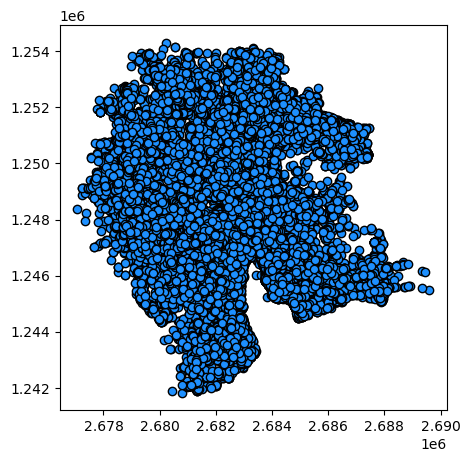

In [24]:
# Instantly visualize the geometric shapes
zwn_zh_dist_pop_gdf.plot(figsize=(8, 5), color="dodgerblue", edgecolor="black");
# 2. Peek
print(zwn_zh_dist_pop_gdf.crs)

In [30]:
zwn_zh_dist_pop_gdf[
    zwn_zh_dist_pop_gdf["index_right"].isna()
]

,objectid_left,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry_zwn,requested_date,agency_sent_date,updated_date,index_right,objectid_right,qnr,qname,knr,kname,poptot2025,poptot2024,poptot2023,poptot2022,poptot2021,poptot2020,poptot2019,poptot2018,poptot2017,poptot2016,poptot2015,poptot2014,poptot2013
19099,19063,20682,2019-08-08 18:21:24,2019-08-09 09:37:03,2019-08-09 10:17:53,2682551,1252291,Signalisation/Lichtsignal,Signalisation/Lichtsignal,fixed - council,16624,Schmiererei,Schmiererei,https://www.zueriwieneu.ch/photo/20682.0.jpeg?...,iOS,Die Signalisationen werden periodisch und gebi...,Schmiererei: Schmiererei,https://www.zueriwieneu.ch/report/20682,POINT (2682551 1252291),2019-08-08,2019-08-09,2019-08-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20262,20222,21901,2019-10-13 18:07:22,2019-10-13 18:12:03,2019-10-14 08:18:53,2686455,1245068,Graffiti,Graffiti,fixed - council,16624,Der Stromka,Der Stromkasten bei der S18 Station Zürich Reh...,https://www.zueriwieneu.ch/photo/21901.0.jpeg?...,Web interface,Besten Dank für Ihre Meldung auf «Züri wie neu...,Der Stromka: Der Stromkasten bei der S18 Stati...,https://www.zueriwieneu.ch/report/21901,POINT (2686455 1245068),2019-10-13,2019-10-13,2019-10-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22276,22235,24036,2020-04-13 12:47:47,2020-04-13 12:52:02,2020-04-14 15:35:40,2686912,1249969,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,16624,Behälter fü,Behälter für Hundekot und Abfallbehälter überf...,https://www.zueriwieneu.ch/photo/24036.0.jpeg?...,iOS,ERZ Entsorgung + Recycling Zürich leitet Ihr A...,Behälter fü: Behälter für Hundekot und Abfallb...,https://www.zueriwieneu.ch/report/24036,POINT (2686912 1249969),2020-04-13,2020-04-13,2020-04-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22414,22373,24180,2020-04-21 15:43:53,2020-04-23 16:27:02,2020-04-23 16:27:02,2684749,1252537,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,external,16624,An der Tram,An der Tramhaltestelle Fernsehstudio stürzte m...,https://www.zueriwieneu.ch/photo/24180.0.jpeg?...,Web interface,Besten Dank für Ihre Meldung auf «Züri wie neu...,An der Tram: An der Tramhaltestelle Fernsehstu...,https://www.zueriwieneu.ch/report/24180,POINT (2684749 1252537),2020-04-21,2020-04-23,2020-04-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45968,45949,51186,2023-11-17 09:29:50,2023-11-21 11:32:04,2023-11-21 17:24:59,2685291,1244599,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf der Zol,"Auf der Zollikerstrasse, an der Stadtgrenze st...",NaN,iOS,Besten Dank für Ihre Meldung auf «Züri wie neu...,"Auf der Zol: Auf der Zollikerstrasse, an der S...",https://www.zueriwieneu.ch/report/51186,POINT (2685291 1244599),2023-11-17,2023-11-21,2023-11-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
51603,51558,57742,2024-06-24 09:42:31,2024-06-24 09:47:04,2024-06-24 10:03:10,2677550,1250203,Signalisation/Lichtsignal,Signalisation/Lichtsignal,fixed - council,14808,Auto auf de,Auto auf der Tafel verklebt,https://www.zueriwieneu.ch/photo/57742.0.jpeg?...,iOS,Guten Tag <br/> <br/> Vielen Dank für Ihre Me...,Auto auf de: Auto auf der Tafel verklebt,https://www.zueriwieneu.ch/report/57742,POINT (2677550 1250203),2024-06-24,2024-06-24,2024-06-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57890,57841,64685,2025-01-06 18:35:19,2025-01-06 18:37:05,2025-01-07 10:44:28,2684345,1252798,Signalisation/Lichtsignal,Signalisation/Lichtsignal,fixed - council,16086,Rote Drücke,Rote Drücker an Fussgänger-Ampel fehlt. Es han...,https://www.zueriwieneu.ch/photo/64685.0.jpeg?...,iOS,Guten Tag <br/> <br/> Vielen Dank für Ihren w...,Rote Drücke: Rote Drücker an Fussgänger-Ampel ...,https

Text(0.5, 1.0, 'Punkte ohne Polygon-Zuordnung')

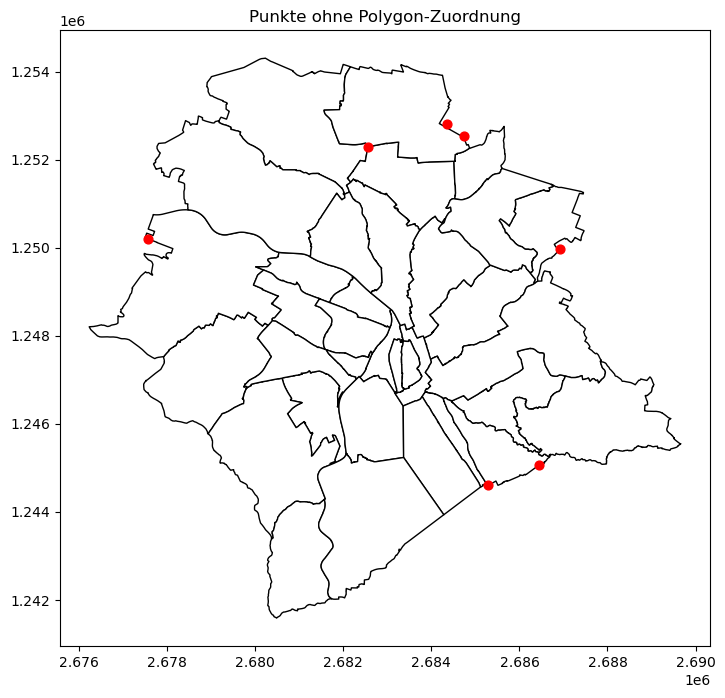

In [31]:
# Punkte ohne Match finden
no_match = zwn_zh_dist_pop_gdf[
    zwn_zh_dist_pop_gdf["index_right"].isna()
]

ax = zh_dist_pop_gdf.plot(
    figsize=(10, 8),
    color="white",
    edgecolor="black"
)

no_match.plot(
    ax=ax,
    color="red",
    markersize=40
)

ax.set_title("Punkte ohne Polygon-Zuordnung")

In [32]:
zwn_zh_dist_pop_gdf = gpd.sjoin(
    zwn_interp_gdf,
    zh_dist_pop_gdf,
    how="left",
    predicate="within"
)

pd.set_option("display.max_columns", None)

zwn_zh_dist_pop_gdf[
    zwn_zh_dist_pop_gdf["index_right"].isna()
]

# 2. Peek
print(zwn_zh_dist_pop_gdf.crs)
display(zwn_zh_dist_pop_gdf.head(10))
display(zwn_zh_dist_pop_gdf.tail(10))

# 3. Shape & Columns
print(zwn_zh_dist_pop_gdf.shape)
print(zwn_zh_dist_pop_gdf.columns.values)
print(zwn_zh_dist_pop_gdf.crs)
display(zwn_zh_dist_pop_gdf.info())

EPSG:2056


,objectid_left,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry_zwn,requested_date,agency_sent_date,updated_date,index_right,objectid_right,qnr,qname,knr,kname,poptot2025,poptot2024,poptot2023,poptot2022,poptot2021,poptot2020,poptot2019,poptot2018,poptot2017,poptot2016,poptot2015,poptot2014,poptot2013
0,1,1,2013-03-14 15:16:15,2013-04-04 07:25:05,2013-04-12 07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548),2013-03-14,2013-04-04,2013-04-12,1.0,9.0,91.0,Albisrieden,9.0,Kreis 9,24304.0,23877.0,23526.0,22875.0,22412.0,22364.0,22352.0,22304.0,22113.0,21174.0,19325.0,19199.0,19146.0
1,2,2,2013-03-14 15:17:57,2013-03-26 14:05:05,2013-04-12 08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916),2013-03-14,2013-03-26,2013-04-12,15.0,19.0,101.0,Höngg,10.0,Kreis 10,24981.0,24810.0,24674.0,24807.0,24510.0,24439.0,24358.0,24020.0,23797.0,23423.0,22320.0,21826.0,21581.0
2,3,4,2013-03-15 09:14:16,2013-03-15 09:55:05,2013-04-12 08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431),2013-03-15,2013-03-15,2013-04-12,23.0,26.0,121.0,Saatlen,12.0,Kreis 12,8852.0,8814.0,8865.0,8826.0,8788.0,8799.0,8841.0,8582.0,8388.0,8283.0,8508.0,7563.0,7280.0
3,4,5,2013-03-15 09:17:15,2013-03-20 10:05:05,2013-04-12 08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Par,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376),2013-03-15,2013-03-20,2013-04-12,31.0,17.0,102.0,Wipkingen,10.0,Kreis 10,16745.0,16734.0,16737.0,16698.0,16507.0,16605.0,16474.0,16321.0,16544.0,16141.0,15879.0,15717.0,15835.0
4,5,6,2013-03-15 10:36:53,2013-04-22 18:25:05,2013-04-23 13:50:33,2683094,1247762,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,16624,Arbeitskist,Arbeitskiste ist rund herum verschmiert,https://www.zueriwieneu.ch/photo/6.0.jpeg?8e65...,Web interface,Dieses Graffiti wird von uns in den kommenden ...,Arbeitskist: Arbeitskiste ist rund herum versc...,https://www.zueriwieneu.ch/report/6,POINT (2683094 1247762),2013-03-15,2013-04-22,2013-04-23,4.0,22.0,14.0,City,1.0,Kreis 1,769.0,785.0,806.0,820.0,817.0,829.0,797.0,829.0,830.0,810.0,805.0,791.0,783.0
5,6,7,2013-03-16 17:54:42,2013-03-28 07:10:05,2013-04-12 08:09:44,2683475,1247422,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Gelockerte,Gelockerte und fehlende Pflastersteine auf der...,https://www.zueriwieneu.ch/photo/7.0.jpeg?eefa...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Gelockerte : Gelockerte und fehlende Pflasters...,https://www.zueriwieneu.ch/report/7,POINT (2683475 1247422),2013-03-16,2013-03-28,2013-04-12,22.0,23.0,11.0,Rathaus,1.0,Kreis 1,3252.0,3260.0,3343.0,3330.0,3275.0,3317.0,3307.0,3267.0,3266.0,3226.0,3197.0,3236.0,3194.0
6,7,8,2013-03-16 18:04:21,2013-05-06 15:50:05,2013-05-

,objectid_left,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry_zwn,requested_date,agency_sent_date,updated_date,index_right,objectid_right,qnr,qname,knr,kname,poptot2025,poptot2024,poptot2023,poptot2022,poptot2021,poptot2020,poptot2019,poptot2018,poptot2017,poptot2016,poptot2015,poptot2014,poptot2013
72918,72919,81475,2026-05-08 09:43:08,2026-05-08 09:47:05,2026-05-08 11:20:47,2681853,1246346,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,3029,Ein Sofa li,Ein Sofa liegt unter der Brücke.,https://www.zueriwieneu.ch/photo/81475.0.jpeg?...,mobile,Entsorgung + Recycling Zürich holt den gemelde...,Ein Sofa li: Ein Sofa liegt unter der Brücke.,https://www.zueriwieneu.ch/report/81475,POINT (2681853 1246346),2026-05-08,2026-05-08,2026-05-08,2.0,33.0,31.0,Alt-Wiedikon,3.0,Kreis 3,18904.0,18610.0,18115.0,18079.0,17631.0,17764.0,17874.0,17956.0,17522.0,17321.0,17158.0,16918.0,16706.0
72919,72920,81477,2026-05-08 10:39:03,2026-05-08 11:12:05,2026-05-08 11:12:05,2681282,1242686,Allgemein,Allgemein,external,3971,Dieser Roll,Dieser Roller steht schon seit 3 Wochen auf de...,https://www.zueriwieneu.ch/photo/81477.0.jpeg?...,desktop,Vielen Dank für Ihre Meldung. Wir haben sie an...,Dieser Roll: Dieser Roller steht schon seit 3 ...,https://www.zueriwieneu.ch/report/81477,POINT (2681282 1242686),2026-05-08,2026-05-08,2026-05-08,17.0,6.0,23.0,Leimbach,2.0,Kreis 2,6316.0,6415.0,6423.0,6462.0,6338.0,6140.0,6152.0,6320.0,6212.0,6173.0,6102.0,5936.0,5730.0
72920,72921,81478,2026-05-08 10:52:45,2026-05-08 10:57:05,2026-05-08 12:22:43,2684828,1251822,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,12710,Gruezi mite,Gruezi mitenand Da wurde offebar diese Woche n...,NaN,iOS,Entsorgung + Recycling Zürich leitet Ihr Anlie...,Gruezi mite: Gruezi mitenand Da wurde offebar ...,https://www.zueriwieneu.ch/report/81478,POINT (2684828 1251822),2026-05-08,2026-05-08,2026-05-08,23.0,26.0,121.0,Saatlen,12.0,Kreis 12,8852.0,8814.0,8865.0,8826.0,8788.0,8799.0,8841.0,8582.0,8388.0,8283.0,8508.0,7563.0,7280.0
72921,72922,81479,2026-05-08 11:00:26,2026-05-08 11:02:07,2026-05-08 11:25:56,2681016,1249418,Beleuchtung/Uhren,Beleuchtung/Uhren,fixed - council,6076,Light on du,Light on during day,NaN,iOS,Besten Dank für Ihre Nachricht. <br/> Dass die...,Light on du: Light on during day,https://www.zueriwieneu.ch/report/81479,POINT (2681016 1249418),2026-05-08,2026-05-08,2026-05-08,6.0,13.0,52.0,Escher Wyss,5.0,Kreis 5,6426.0,6077.0,6185.0,6225.0,6221.0,6198.0,6188.0,6066.0,6088.0,5825.0,5457.0,4604.0,4010.0
72922,72923,81480,2026-05-08 11:08:39,2026-05-08 11:12:05,2026-05-08 17:19:05,2678944,1247548,Schädlinge,Schädlinge,fixed - council,18925,Warscheinli,Warscheinlich Gespinstmotte¨ <br/> <br/> Bin ...,https://www.zueriwieneu.ch/photo/81480.0.jpeg?...,desktop,Vielen Dank für Ihre Meldung. Die Gespinstmott...,Warscheinli: Warscheinlich Gespinstmotte¨ <br/...,https://www.zueriwieneu.ch/report/81480,POINT (2678944 1247548),2026-05-08,2026-05-08,2026-05-08,1.0,9.0,91.0,Albisrieden,9.0,Kreis 9,24304.0,23877.0,23526.0,22875.0,22412.0,22364.0,22352.0,22304.0,22113.0,21174.0,19325.0,19199.0,19146.0
72923,72924,81485,2026-05-08 12:35:15,2026-05-08 12:37:06,2026-05-08 13:37:04,2680717,1246225,Signalisation/Lichtsignal,Signalisation/Lichtsignal,fixed - council,16680,HV Tafel ve,HV Tafel verdreht,https://www.zueriwieneu.ch/photo/81485.0.jpeg?...,iOS,Guten Tag und vielen Dank für Ihre Meldung. <b...,HV Tafel ve: HV Tafel verdreht,https://www.zueriwieneu.ch/report/81485,POINT (2680717 1246225),2026-05-08,2026-05-08,2026-05-08,8.0,28.0,33.0,Friesenberg,3.0,Kreis 3,11226.0,11137.0,11082.0,10861.0,10957.0,11071.0,11107.0,10933.0,10860.0,11002.0,10698.0,10695.0,10696.0
72924,72925,81488,2026-05-08 14:22:41,2026-05-08 14:27:06,2026-05-08 16:40:54,2681081,1248091,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,14824,Teppich,T

(72928, 41)
<ArrowStringArray>
[       'objectid_left',   'service_request_id',   'requested_datetime',
 'agency_sent_datetime',     'updated_datetime',                    'e',
                    'n',         'service_code',         'service_name',
               'status',               'userid',                'title',
               'detail',            'media_url',       'interface_used',
       'service_notice',          'description',                  'url',
         'geometry_zwn',       'requested_date',     'agency_sent_date',
         'updated_date',          'index_right',       'objectid_right',
                  'qnr',                'qname',                  'knr',
                'kname',           'poptot2025',           'poptot2024',
           'poptot2023',           'poptot2022',           'poptot2021',
           'poptot2020',           'poptot2019',           'poptot2018',
           'poptot2017',           'poptot2016',           'poptot2015',
           'poptot20

None

Text(0.5, 1.0, 'Punkte ohne Polygon-Zuordnung')

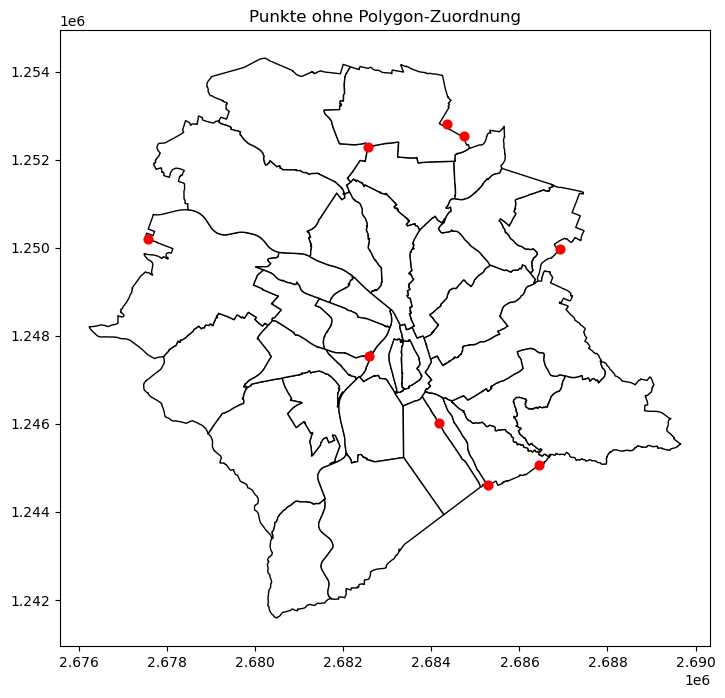

In [33]:
# Punkte ohne Match finden
no_match = zwn_zh_dist_pop_gdf[
    zwn_zh_dist_pop_gdf["index_right"].isna()
]

ax = zh_dist_pop_gdf.plot(
    figsize=(10, 8),
    color="white",
    edgecolor="black"
)

no_match.plot(
    ax=ax,
    color="red",
    markersize=40
)

ax.set_title("Punkte ohne Polygon-Zuordnung")

In [34]:
zwn_zh_dist_pop_gdf = gpd.sjoin_nearest(
    zwn_interp_gdf,
    zh_dist_pop_gdf,
    how="left",
    distance_col="dist_to_polygon"
)

pd.set_option("display.max_columns", None)

zwn_zh_dist_pop_gdf[
    zwn_zh_dist_pop_gdf["index_right"].isna()
]

# 2. Peek
print(zwn_zh_dist_pop_gdf.crs)
display(zwn_zh_dist_pop_gdf.head(10))
display(zwn_zh_dist_pop_gdf.tail(10))

# 3. Shape & Columns
print(zwn_zh_dist_pop_gdf.shape)
print(zwn_zh_dist_pop_gdf.columns.values)
print(zwn_zh_dist_pop_gdf.crs)
display(zwn_zh_dist_pop_gdf.info())

EPSG:2056


,objectid_left,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry_zwn,requested_date,agency_sent_date,updated_date,index_right,objectid_right,qnr,qname,knr,kname,poptot2025,poptot2024,poptot2023,poptot2022,poptot2021,poptot2020,poptot2019,poptot2018,poptot2017,poptot2016,poptot2015,poptot2014,poptot2013,dist_to_polygon
0,1,1,2013-03-14 15:16:15,2013-04-04 07:25:05,2013-04-12 07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548),2013-03-14,2013-04-04,2013-04-12,1,9,91,Albisrieden,9,Kreis 9,24304,23877,23526,22875,22412,22364,22352,22304,22113,21174,19325,19199,19146,0.0
1,2,2,2013-03-14 15:17:57,2013-03-26 14:05:05,2013-04-12 08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916),2013-03-14,2013-03-26,2013-04-12,15,19,101,Höngg,10,Kreis 10,24981,24810,24674,24807,24510,24439,24358,24020,23797,23423,22320,21826,21581,0.0
2,3,4,2013-03-15 09:14:16,2013-03-15 09:55:05,2013-04-12 08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431),2013-03-15,2013-03-15,2013-04-12,23,26,121,Saatlen,12,Kreis 12,8852,8814,8865,8826,8788,8799,8841,8582,8388,8283,8508,7563,7280,0.0
3,4,5,2013-03-15 09:17:15,2013-03-20 10:05:05,2013-04-12 08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Par,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376),2013-03-15,2013-03-20,2013-04-12,31,17,102,Wipkingen,10,Kreis 10,16745,16734,16737,16698,16507,16605,16474,16321,16544,16141,15879,15717,15835,0.0
4,5,6,2013-03-15 10:36:53,2013-04-22 18:25:05,2013-04-23 13:50:33,2683094,1247762,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,16624,Arbeitskist,Arbeitskiste ist rund herum verschmiert,https://www.zueriwieneu.ch/photo/6.0.jpeg?8e65...,Web interface,Dieses Graffiti wird von uns in den kommenden ...,Arbeitskist: Arbeitskiste ist rund herum versc...,https://www.zueriwieneu.ch/report/6,POINT (2683094 1247762),2013-03-15,2013-04-22,2013-04-23,4,22,14,City,1,Kreis 1,769,785,806,820,817,829,797,829,830,810,805,791,783,0.0
5,6,7,2013-03-16 17:54:42,2013-03-28 07:10:05,2013-04-12 08:09:44,2683475,1247422,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Gelockerte,Gelockerte und fehlende Pflastersteine auf der...,https://www.zueriwieneu.ch/photo/7.0.jpeg?eefa...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Gelockerte : Gelockerte und fehlende Pflasters...,https://www.zueriwieneu.ch/report/7,POINT (2683475 1247422),2013-03-16,2013-03-28,2013-04-12,22,23,11,Rathaus,1,Kreis 1,3252,3260,3343,3330,3275,3317,3307,3267,3266,3226,3197,3236,3194,0.0
6,7,8,2013-03-16 18:04:21,2013-05-06 15:50:05,2013-05-06 17:29:11,2683303,1247675,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Steinerne B,"Steinerne Ballustrade bei der Uraniawache, Bah...",http

,objectid_left,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry_zwn,requested_date,agency_sent_date,updated_date,index_right,objectid_right,qnr,qname,knr,kname,poptot2025,poptot2024,poptot2023,poptot2022,poptot2021,poptot2020,poptot2019,poptot2018,poptot2017,poptot2016,poptot2015,poptot2014,poptot2013,dist_to_polygon
72918,72919,81475,2026-05-08 09:43:08,2026-05-08 09:47:05,2026-05-08 11:20:47,2681853,1246346,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,3029,Ein Sofa li,Ein Sofa liegt unter der Brücke.,https://www.zueriwieneu.ch/photo/81475.0.jpeg?...,mobile,Entsorgung + Recycling Zürich holt den gemelde...,Ein Sofa li: Ein Sofa liegt unter der Brücke.,https://www.zueriwieneu.ch/report/81475,POINT (2681853 1246346),2026-05-08,2026-05-08,2026-05-08,2,33,31,Alt-Wiedikon,3,Kreis 3,18904,18610,18115,18079,17631,17764,17874,17956,17522,17321,17158,16918,16706,0.0
72919,72920,81477,2026-05-08 10:39:03,2026-05-08 11:12:05,2026-05-08 11:12:05,2681282,1242686,Allgemein,Allgemein,external,3971,Dieser Roll,Dieser Roller steht schon seit 3 Wochen auf de...,https://www.zueriwieneu.ch/photo/81477.0.jpeg?...,desktop,Vielen Dank für Ihre Meldung. Wir haben sie an...,Dieser Roll: Dieser Roller steht schon seit 3 ...,https://www.zueriwieneu.ch/report/81477,POINT (2681282 1242686),2026-05-08,2026-05-08,2026-05-08,17,6,23,Leimbach,2,Kreis 2,6316,6415,6423,6462,6338,6140,6152,6320,6212,6173,6102,5936,5730,0.0
72920,72921,81478,2026-05-08 10:52:45,2026-05-08 10:57:05,2026-05-08 12:22:43,2684828,1251822,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,12710,Gruezi mite,Gruezi mitenand Da wurde offebar diese Woche n...,NaN,iOS,Entsorgung + Recycling Zürich leitet Ihr Anlie...,Gruezi mite: Gruezi mitenand Da wurde offebar ...,https://www.zueriwieneu.ch/report/81478,POINT (2684828 1251822),2026-05-08,2026-05-08,2026-05-08,23,26,121,Saatlen,12,Kreis 12,8852,8814,8865,8826,8788,8799,8841,8582,8388,8283,8508,7563,7280,0.0
72921,72922,81479,2026-05-08 11:00:26,2026-05-08 11:02:07,2026-05-08 11:25:56,2681016,1249418,Beleuchtung/Uhren,Beleuchtung/Uhren,fixed - council,6076,Light on du,Light on during day,NaN,iOS,Besten Dank für Ihre Nachricht. <br/> Dass die...,Light on du: Light on during day,https://www.zueriwieneu.ch/report/81479,POINT (2681016 1249418),2026-05-08,2026-05-08,2026-05-08,6,13,52,Escher Wyss,5,Kreis 5,6426,6077,6185,6225,6221,6198,6188,6066,6088,5825,5457,4604,4010,0.0
72922,72923,81480,2026-05-08 11:08:39,2026-05-08 11:12:05,2026-05-08 17:19:05,2678944,1247548,Schädlinge,Schädlinge,fixed - council,18925,Warscheinli,Warscheinlich Gespinstmotte¨ <br/> <br/> Bin ...,https://www.zueriwieneu.ch/photo/81480.0.jpeg?...,desktop,Vielen Dank für Ihre Meldung. Die Gespinstmott...,Warscheinli: Warscheinlich Gespinstmotte¨ <br/...,https://www.zueriwieneu.ch/report/81480,POINT (2678944 1247548),2026-05-08,2026-05-08,2026-05-08,1,9,91,Albisrieden,9,Kreis 9,24304,23877,23526,22875,22412,22364,22352,22304,22113,21174,19325,19199,19146,0.0
72923,72924,81485,2026-05-08 12:35:15,2026-05-08 12:37:06,2026-05-08 13:37:04,2680717,1246225,Signalisation/Lichtsignal,Signalisation/Lichtsignal,fixed - council,16680,HV Tafel ve,HV Tafel verdreht,https://www.zueriwieneu.ch/photo/81485.0.jpeg?...,iOS,Guten Tag und vielen Dank für Ihre Meldung. <b...,HV Tafel ve: HV Tafel verdreht,https://www.zueriwieneu.ch/report/81485,POINT (2680717 1246225),2026-05-08,2026-05-08,2026-05-08,8,28,33,Friesenberg,3,Kreis 3,11226,11137,11082,10861,10957,11071,11107,10933,10860,11002,10698,10695,10696,0.0
72924,72925,81488,2026-05-08 14:22:41,2026-05-08 14:27:06,2026-05-08 16:40:54,2681081,1248091,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,14824,Teppich,Teppich,https://www.zueriwieneu.ch/photo/81488.0.jpeg?...,iOS,Entsorgung + Recycling Zürich holt den gemelde...,Teppich: Teppich,https://www.zueriwieneu.ch/report/81

(72930, 42)
<ArrowStringArray>
[       'objectid_left',   'service_request_id',   'requested_datetime',
 'agency_sent_datetime',     'updated_datetime',                    'e',
                    'n',         'service_code',         'service_name',
               'status',               'userid',                'title',
               'detail',            'media_url',       'interface_used',
       'service_notice',          'description',                  'url',
         'geometry_zwn',       'requested_date',     'agency_sent_date',
         'updated_date',          'index_right',       'objectid_right',
                  'qnr',                'qname',                  'knr',
                'kname',           'poptot2025',           'poptot2024',
           'poptot2023',           'poptot2022',           'poptot2021',
           'poptot2020',           'poptot2019',           'poptot2018',
           'poptot2017',           'poptot2016',           'poptot2015',
           'poptot20

None

In [36]:
duplicates = zwn_zh_dist_pop_gdf[
    zwn_zh_dist_pop_gdf.duplicated(
        subset="objectid_left",
        keep=False
    )
]

display(duplicates)

,objectid_left,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry_zwn,requested_date,agency_sent_date,updated_date,index_right,objectid_right,qnr,qname,knr,kname,poptot2025,poptot2024,poptot2023,poptot2022,poptot2021,poptot2020,poptot2019,poptot2018,poptot2017,poptot2016,poptot2015,poptot2014,poptot2013,dist_to_polygon
16464,16428,17892,2019-02-23 11:42:54,2019-02-23 11:47:02,2019-03-04 07:53:12,2682577,1247532,Graffiti,Graffiti,fixed - council,16624,Graffiti an,Graffiti an Schaltkasten,https://www.zueriwieneu.ch/photo/17892.0.jpeg?...,iOS,Besten Dank für Ihre Meldung auf «Züri wie neu...,Graffiti an: Graffiti an Schaltkasten,https://www.zueriwieneu.ch/report/17892,POINT (2682577 1247532),2019-02-23,2019-02-23,2019-03-04,30,7,41,Werd,4,Kreis 4,4585,4495,4650,4515,4574,4570,4455,4455,4574,4594,4460,4428,4188,0.0
16464,16428,17892,2019-02-23 11:42:54,2019-02-23 11:47:02,2019-03-04 07:53:12,2682577,1247532,Graffiti,Graffiti,fixed - council,16624,Graffiti an,Graffiti an Schaltkasten,https://www.zueriwieneu.ch/photo/17892.0.jpeg?...,iOS,Besten Dank für Ihre Meldung auf «Züri wie neu...,Graffiti an: Graffiti an Schaltkasten,https://www.zueriwieneu.ch/report/17892,POINT (2682577 1247532),2019-02-23,2019-02-23,2019-03-04,16,12,42,Langstrasse,4,Kreis 4,11978,11869,11982,11977,11815,11910,11853,11111,11144,11145,11169,10985,10686,0.0
62551,62518,69858,2025-06-09 13:46:45,2025-06-09 13:47:05,2025-06-10 08:50:12,2684170,1246008,Signalisation/Lichtsignal,Signalisation/Lichtsignal,fixed - council,13408,"VZ ""Fussgän","VZ ""Fussgängerüberweg"" ist vedreht und nicht g...",https://www.zueriwieneu.ch/photo/69858.0.jpeg?...,Android,Guten Tag <br/> <br/> Vielen Dank für Ihren w...,"VZ ""Fussgän: VZ ""Fussgängerüberweg"" ist vedreh...",https://www.zueriwieneu.ch/report/69858,POINT (2684170 1246008),2025-06-09,2025-06-09,2025-06-10,26,4,81,Seefeld,8,Kreis 8,5798,5807,5777,5815,5862,5480,5319,5253,5129,5046,4990,5035,4978,0.0
62551,62518,69858,2025-06-09 13:46:45,2025-06-09 13:47:05,2025-06-10 08:50:12,2684170,1246008,Signalisation/Lichtsignal,Signalisation/Lichtsignal,fixed - council,13408,"VZ ""Fussgän","VZ ""Fussgängerüberweg"" ist vedreht und nicht g...",https://www.zueriwieneu.ch/photo/69858.0.jpeg?...,Android,Guten Tag <br/> <br/> Vielen Dank für Ihren w...,"VZ ""Fussgän: VZ ""Fussgängerüberweg"" ist vedreh...",https://www.zueriwieneu.ch/report/69858,POINT (2684170 1246008),2025-06-09,2025-06-09,2025-06-10,19,3,82,Mühlebach,8,Kreis 8,6437,6456,6494,6440,6408,6414,6327,6315,6164,6137,6116,6107,5912,0.0


Anzahl problematischer Punkte: 2


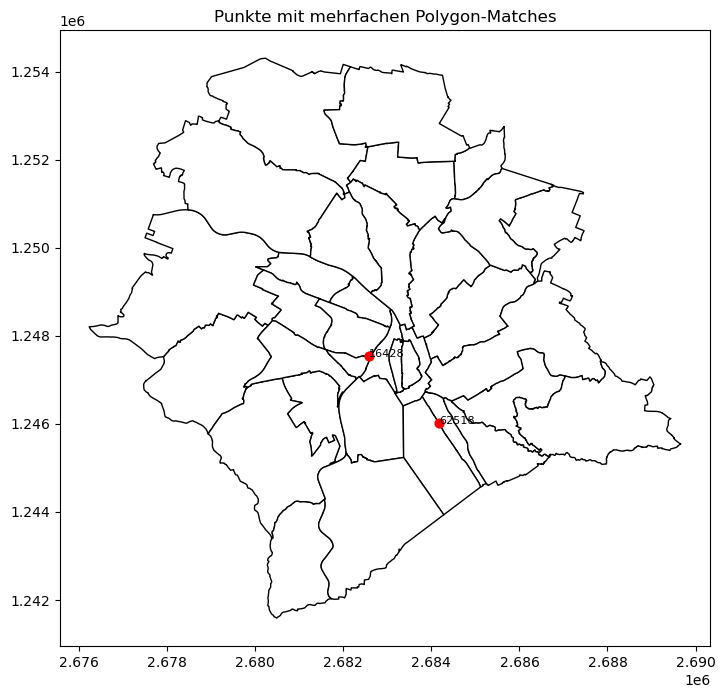

In [39]:
# Punkte mit mehrfachen Matches finden
duplicate_points = zwn_zh_dist_pop_gdf[
    zwn_zh_dist_pop_gdf.duplicated(
        subset="objectid_left",
        keep=False
    )
]

# Nur eindeutige Punkte behalten
duplicate_points_unique = (
    duplicate_points
    .drop_duplicates(subset="objectid_left")
)

# Karte plotten
ax = zh_dist_pop_gdf.plot(
    figsize=(10, 8),
    color="white",
    edgecolor="black"
)

# Problematische Punkte rot darstellen
duplicate_points_unique.plot(
    ax=ax,
    color="red",
    markersize=40
)

# Labels anzeigen
for idx, row in duplicate_points_unique.iterrows():

    geom = row["geometry_zwn"]   # <- Spaltenname anpassen falls nötig

    ax.annotate(
        text=str(row["objectid_left"]),
        xy=(geom.x, geom.y),
        fontsize=8
    )

ax.set_title("Punkte mit mehrfachen Polygon-Matches")

print(f"Anzahl problematischer Punkte: {len(duplicate_points_unique)}")

In [ ]:
# Export as a GeoPackage (For sharing with QGIS/ArcGIS users)
zwn_zh_dist_pop_gdf.to_file("data/processed/stzh.adm.pop_statistische_quartiere_map_processed.gpkg")

print("File successfully saved!")